In [55]:
from constants import users_list, data_path
from lib import spoti, genre_normalizer, plotting, preprocessing, dimensionality_reduction, user_similarities

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import json
import os
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torch.nn import functional as F
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from sklearn.metrics import mean_squared_error
import random
import time
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors, NeighborhoodComponentsAnalysis
from sklearn.metrics import pairwise_distances
import pickle
import numpy as np
from typing import List, Dict, Tuple, Optional, Any, Callable
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from IPython.display import display, HTML
from lib.matrix_dataset import MatrixDataset
from recommenders.vae import MultiVAE
from recommenders.metrics import NDCG_binary_at_k_batch, Recall_at_k_batch_torch, mpr
import datetime

In [56]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

if torch.backends.mps.is_available():
    mps_device = torch.device("mps")
    device = mps_device
    x = torch.ones(1, device=mps_device)
    print(x)
else:
    print ("MPS device not found.")

if device == torch.device("cuda"):
    dtype = torch.float32
    print("Using CUDA.")
elif device == torch.device("cpu"):
    dtype = torch.float64
    print("Using CPU.")
elif device == torch.device("mps"):
    dtype = torch.float32
    print("Using MPS.")

# device = "cpu"
# dtype = torch.float32

tensor([1.], device='mps:0')
Using MPS.


In [57]:
torch.manual_seed(42)
np.random.seed(42)

# Import data

In [58]:
df = spoti.load_all_tracks(
    base_path=data_path.DATA_PATH,
    users=users_list.USERS,
    top_tracks_affinity_start = {
        "short_term": 1.0,
        "medium_term": 0.7,
        "long_term": 0.5,
    },
    top_tracks_affinity_end = {
        "short_term": 0.5,
        "medium_term": 0.4,
        "long_term": 0.3,
    },
    top_tracks_include_end=False,
    liked_tracks_start_affinity=0.7,
    liked_tracks_end_affinity=0.1,
    liked_tracks_include_endpoint=False,
    load_spotify_tracks=False,
    playlists_affinity=0.2,
)
df

,album,artists,available_markets,disc_number,duration_ms,explicit,external_ids,external_urls,href,id,...,time_range,affinity,username,release_year,normalized_genres,added_at,episode,track,added_by,playlist_id
0,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,196426,False,{'isrc': 'USSM12301260'},{'spotify': 'https://open.spotify.com/track/75...,https://api.spotify.com/v1/tracks/75rqqKvzJCGv...,75rqqKvzJCGv2oq9C4yFDt,...,medium_term,0.700,daniel,2023,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
1,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,137533,True,{'isrc': 'USSM12109218'},{'spotify': 'https://open.spotify.com/track/2F...,https://api.spotify.com/v1/tracks/2FYGZDfsAnNs...,2FYGZDfsAnNsrm1gVbyKnG,...,medium_term,0.694,daniel,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
2,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,162906,True,{'isrc': 'USSM12109222'},{'spotify': 'https://open.spotify.com/track/4k...,https://api.spotify.com/v1/tracks/4kroNlz8BTfs...,4kroNlz8BTfswE4M0i3YCh,...,medium_term,0.688,daniel,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
3,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,89749,False,{'isrc': 'USSM12208854'},{'spotify': 'https://open.spotify.com/track/2N...,https://api.spotify.com/v1/tracks/2N3YZ075lq9z...,2N3YZ075lq9z1ObaAiX6l1,...,medium_term,0.682,daniel,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
4,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,174044,False,{'isrc': 'USSM12300114'},{'spotify': 'https://open.spotify.com/track/2S...,https://api.spotify.com/v1/tracks/2SiAcexM2p1y...,2SiAcexM2p1yX6joESbehd,...,medium_term,0.676,daniel,2023,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10230,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, BY, CH, CW, C...",1,251880,False,{'isrc': 'GBN9Y1100001'},{'spotify': 'https://open.spotify.com/track/3z...,https://api.spotify.com/v1/tracks/3z7dWKRsjDNM...,3z7dWKRsjDNM24ohLKZBnA,...,NaN,0.200,todd,1967,"[rock, rock, rock, rock, rock, rock, rock]",2022-12-30 08:42:31+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
10231,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,193853,False,{'isrc': 'GBLTP1700005'},{'spotify': 'https://open.spotify.com/track/1V...,https://api.spotify.com/v1/tracks/1VofMhhL98pe...,1VofMhhL98pewltVGBSmCW,...,NaN,0.200,todd,2017,"[rock, rock, rock, rock, rock]",2020-08-10 14:53:07+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
10232,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,295493,False,{'isrc': 'GBLTP1700011'},{'spotify': 'https://open.spotify.com/track/0K...,https://api.spotify.com/v1/tracks/0KE7apgczHNY...,0KE7apgczHNYiXIvMUY0Fc,...,NaN,0.200,todd,2017,"[rock, rock, rock, rock, rock]",2020-08-10 14:53:13+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
10233,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,467306,False,{'isrc': 'GBLTP1700014'},{'spotify': 'https://open.spotify.com/track/6v...,https://api.spotify.com/v1/tracks/6vbRA9yAAgIX...,6vbRA9yAAgIXtDlmhyNqP

In [59]:
n_dataset = 128
df = pd.read_csv(os.path.join(data_path.DATA_PATH, f"artificial_data_{n_dataset}.csv"), index_col=0)
df["type"] = "top_track"
spoti.PRETTY_PRINT_FEATURES = ["username", "id", "danceability", "instrumentalness", "duration_ms"]
df

,id,username,danceability,energy,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,loudness,duration_ms,release_year,time_signature,popularity,affinity,type
0,Serious available open even. International war...,Rhonda Spears,1.037357,0.902853,1.042395,0.950693,0.960995,0.912003,1.194481,1.016889,1.202738,0.944171,0.874452,0.996832,0.983082,1.014370,1.006558,top_track
1,Agree cell director its bad,Rhonda Spears,1.006691,1.055318,0.970388,1.070170,1.109789,0.996393,0.929764,0.939280,0.887221,1.141801,1.102384,0.926877,0.861581,1.121396,0.877085,top_track
2,Political time responsibility,Rhonda Spears,0.929774,0.975246,1.211122,1.138555,0.856212,1.057474,1.217815,0.983688,0.910270,0.972319,0.879383,1.042262,0.894509,0.990926,0.841844,top_track
3,Population space see. Mother born two stop score,Rhonda Spears,0.813101,1.097375,0.906068,1.082595,0.911144,0.871657,0.935078,0.938622,1.095688,0.919521,1.162316,0.949425,1.055702,1.011173,1.018994,top_track
4,Especially choice couple must,Rhonda Spears,1.061212,1.031610,0.912801,1.001309,0.983415,0.958604,1.057310,1.100518,0.780049,1.122782,0.821868,0.754511,1.058147,0.986983,1.154644,top_track
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129943,Pretty think culture. Join everyone notice,Michael Dixon,0.954234,1.063253,1.065808,1.135537,1.129608,0.859004,0.857511,0.995485,1.034659,0.912819,0.936339,1.027097,1.058689,0.832793,0.845034,top_track
129944,Life fall list final. Democrat finally offer,Michael Dixon,1.123800,1.030682,0.882804,1.148934,0.957668,1.073466,1.021812,1.086180,0.777490,1.073009,1.016861,0.935485,1.134814,0.996016,0.989838,top_track
129945,None note full benefit attention American account,Michael Dixon,1.086593,1.072595,0.933216,0.928629,1.025741,1.013878,1.100455,0.907902,1.179093,0.833151,0.981570,0.785342,1.013912,0.939939,1.118996,top_track
129946,Relate yourself be measure. Build military pro...,Michael Dixon,0.997237,0.918242,0.924112,1.027477,1.232540,1.055278,1.144405,1.167792,1.104662,1.187663,1.045864,1.036084,0.898737,1.076496,1.187144,top_track


# Setting up the dataset

In [60]:
scaler = StandardScaler()
df[spoti.NUMERICAL_FEATURES] = scaler.fit_transform(df[spoti.NUMERICAL_FEATURES])
df.sort_values(by=["username", "affinity"], ascending=False, inplace=True)
df.drop_duplicates(subset=["username", "id"], inplace=True) # A user can have multiple entries for the same track (if it's in multiple playlists)
df.reset_index(drop=True, inplace=True)

df_matrix_mf = df.copy()
used_types = ["top_track", "liked_track", "playlist"]
# used_types = ["top_track"]
df_matrix_mf = df_matrix_mf[df["type"].isin(used_types)]
df_matrix_mf["id"] = df_matrix_mf["id"].astype("category")
df_matrix_mf["username"] = df_matrix_mf["username"].astype("category")
df_matrix_mf

,id,username,danceability,energy,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,loudness,duration_ms,release_year,time_signature,popularity,affinity,type
0,Star as decade establish,Yvonne Chapman,0.692181,2.664934,-0.190199,2.220187,-0.498003,0.486309,0.678257,-0.005449,-1.668172,1.417584,0.484529,-0.708541,-0.530511,-1.154539,1.330859,top_track
1,Majority let walk whether others,Yvonne Chapman,-1.769402,1.622024,-1.371615,0.627134,-0.184170,1.077701,-0.867610,-0.552487,-0.917085,0.427626,1.337051,0.236158,-0.106990,-0.427710,1.277409,top_track
2,Material beautiful citizen score,Yvonne Chapman,-0.235144,-1.082305,1.818365,-0.082071,-1.919911,-1.043573,0.003613,0.988622,0.095156,1.215559,-1.668914,0.589287,0.168095,-0.383093,1.268539,top_track
3,Manager ok rate country parent laugh conference,Yvonne Chapman,0.441276,1.210930,-1.065671,-0.135413,0.005235,0.049657,0.148954,0.717948,0.683301,0.736616,1.481804,-0.310126,0.650327,-1.371625,1.266341,top_track
4,Behind she always citizen pick,Yvonne Chapman,-1.456082,0.224499,1.505385,-1.576697,-1.763119,0.709969,-1.449046,-0.701763,-1.653370,-0.849538,-0.210206,0.730115,0.890021,0.948708,1.256735,top_track
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129943,Wait business effort with agent. Effect quite ...,Adam Jackson,0.202445,0.269113,-1.084721,1.346988,2.068029,0.613728,-0.752132,1.477850,-1.219613,-1.476712,-0.055875,0.258373,1.246189,0.728208,0.740447,top_track
129944,Activity listen science class might policy,Adam Jackson,1.554921,0.560947,-0.349030,-1.858592,-0.792779,-0.163748,2.018706,0.537538,0.874992,-1.223705,-0.499882,0.176556,-1.353952,0.208227,0.727772,top_track
129945,Score evidence after. Bad modern management us,Adam Jackson,0.181349,-0.129884,0.445359,-0.667085,0.097003,3.107614,-0.184428,0.747984,0.682569,-2.241366,-0.579361,-0.590882,0.236298,-0.951305,0.726340,top_track
129946,Candidate song space example six discuss already,Adam Jackson,-0.147024,-1.083860,0.761028,-0.541259,-2.583925,-1.083404,1.226721,-0.285333,0.549038,-0.424622,-0.101467,1.058991,0.472094,0.002716,0.719767,top_track


In [61]:
df_matrix_mf_filtered = df_matrix_mf.copy()
df_matrix_mf_filtered = preprocessing.filter_rows_by_min_number_of_occurence(df_matrix_mf_filtered, "id", 2)
df_matrix_mf_filtered

,id,username,danceability,energy,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,loudness,duration_ms,release_year,time_signature,popularity,affinity,type
1,Majority let walk whether others,Yvonne Chapman,-1.769402,1.622024,-1.371615,0.627134,-0.184170,1.077701,-0.867610,-0.552487,-0.917085,0.427626,1.337051,0.236158,-0.106990,-0.427710,1.277409,top_track
24,Machine gas letter without affect body,Yvonne Chapman,-0.947513,0.059543,-0.772017,-1.107205,1.953581,-0.120814,0.555953,0.791045,-0.343611,-0.139210,-1.689760,0.526369,-0.187801,1.230909,1.177697,top_track
31,Choose outside lawyer on hour,Yvonne Chapman,-0.567218,-0.106787,-0.330272,-2.112118,-0.624365,-0.215809,-0.701155,1.855036,-0.183435,0.501960,0.217491,1.704994,0.850035,-0.222032,1.170730,top_track
34,Sport care set. And hospital receive ok. Main ...,Yvonne Chapman,-1.982426,0.765237,0.625657,-0.453471,0.676024,-1.047727,-0.078272,0.264224,-0.793925,0.937400,-0.057179,1.443996,0.483225,-0.739279,1.164612,top_track
42,Organization mind sell kitchen this film card,Yvonne Chapman,-0.348342,0.661314,0.445013,0.258455,-0.022808,-0.323483,1.159397,0.768350,0.588020,-1.764600,1.509651,0.252092,1.283752,0.402454,1.154353,top_track
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129918,Everything both manager election speak point,Adam Jackson,-0.324135,1.123119,0.225238,0.149932,0.850183,-0.023702,-0.681628,0.143085,-2.131716,0.612260,-0.665960,-0.202009,0.250036,0.398670,0.800040,top_track
129928,Modern already happen discussion nation messag...,Adam Jackson,0.856121,-0.272822,0.952623,-0.576428,-2.282302,-0.645154,-1.313944,1.070009,1.328535,-0.533157,0.565691,-1.542677,0.672561,0.061337,0.781632,top_track
129939,Home contain sea exactly production she idea foot,Adam Jackson,0.938677,0.846784,1.045932,0.661408,-1.476110,-0.021930,-0.621564,0.471461,-0.533677,0.804341,0.234875,0.673501,1.186992,1.006796,0.757514,top_track
129940,Middle recognize appear list onto dark year,Adam Jackson,-1.387510,-0.127808,0.016832,0.963383,-1.111688,0.853715,0.268965,-0.069274,-0.125503,1.168922,-0.877003,-2.091863,0.062251,1.447742,0.755613,top_track


In [62]:
df_matrix_mf_filtered["id"] = df_matrix_mf_filtered["id"].cat.remove_unused_categories()
df_matrix_mf_filtered["username"] = df_matrix_mf_filtered["username"].cat.remove_unused_categories()

In [63]:
sparsity, users_count, items_count, interactions_count = preprocessing.compute_sparsity(df_matrix_mf_filtered, "username", "id")
print(f"After filtering, there is {len(users_count)} users, {len(items_count)} items and {len(interactions_count)} interactions, so the sparsity is {sparsity*100:.2f}%.")

After filtering, there is 118 users, 4961 items and 10162 interactions, so the sparsity is 1.74%.


In [64]:
users_df = pd.DataFrame(df_matrix_mf_filtered["username"].unique(), columns=["username"]).set_index("username")
(
    train_users_df,
    val_users_df,
    test_users_df,
) = preprocessing.split_users_train_validation_test(
    df_users_shuffled=users_df,
    validation_percentage=0.3,
    test_percentage=0.2,
)
print("Original data:")
display(users_df)
print("Train data:")
display(train_users_df)
print("Validation data:")
display(val_users_df)
print("Test data:")
display(test_users_df)

Original data:


""
username
Yvonne Chapman
Vanessa Bell
Toni Schwartz
Timothy Hampton
Thomas Ramirez
...
Amy Jones
Amanda Long
Alexander Browning


Train data:


""
username
Yvonne Chapman
Vanessa Bell
Toni Schwartz
Timothy Hampton
Thomas Ramirez
...
Joshua Long
Joshua Cline
Jordan Thompson


Validation data:


""
username
John Green
John Fisher
Jessica Medina
Jennifer Cobb
Jeffery Conley
James Maldonado
Jacqueline Morton
Jackie Hopkins
Harold Bauer


Test data:


""
username
Christopher Forbes
Christine Adams
Cheryl Coleman
Chelsey Ramos
Charles Turner
Carrie Thompson
Candice Holden
Cameron Ochoa
Caitlin Page


Train data:


,id,username,danceability,energy,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,loudness,duration_ms,release_year,time_signature,popularity,affinity,type
1,Majority let walk whether others,Yvonne Chapman,-1.769402,1.622024,-1.371615,0.627134,-0.184170,1.077701,-0.867610,-0.552487,-0.917085,0.427626,1.337051,0.236158,-0.106990,-0.427710,1.277409,top_track
24,Machine gas letter without affect body,Yvonne Chapman,-0.947513,0.059543,-0.772017,-1.107205,1.953581,-0.120814,0.555953,0.791045,-0.343611,-0.139210,-1.689760,0.526369,-0.187801,1.230909,1.177697,top_track
31,Choose outside lawyer on hour,Yvonne Chapman,-0.567218,-0.106787,-0.330272,-2.112118,-0.624365,-0.215809,-0.701155,1.855036,-0.183435,0.501960,0.217491,1.704994,0.850035,-0.222032,1.170730,top_track
34,Sport care set. And hospital receive ok. Main ...,Yvonne Chapman,-1.982426,0.765237,0.625657,-0.453471,0.676024,-1.047727,-0.078272,0.264224,-0.793925,0.937400,-0.057179,1.443996,0.483225,-0.739279,1.164612,top_track
42,Organization mind sell kitchen this film card,Yvonne Chapman,-0.348342,0.661314,0.445013,0.258455,-0.022808,-0.323483,1.159397,0.768350,0.588020,-1.764600,1.509651,0.252092,1.283752,0.402454,1.154353,top_track
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66183,Several board evening,John Jackson,0.832687,-1.243781,-3.083100,0.717594,-0.012896,-1.087937,0.397878,-0.085326,-0.602854,-0.906042,-0.662339,-2.011578,0.353287,-0.297095,0.861392,top_track
66185,Finish those rather federal interview third your,John Jackson,-1.575490,-1.299183,0.394872,0.000761,1.764810,0.382730,0.507651,-0.702115,0.291467,1.669279,0.591603,0.995147,-1.051484,-0.692141,0.860676,top_track
66194,Subject next certain newspaper many only simple,John Jackson,-0.548213,-1.943175,-0.244421,1.802181,1.297433,0.339014,0.053491,0.800427,1.121161,0.309991,-0.262605,1.115789,-0.659884,-1.659913,0.853368,top_track
66227,Government I large material marriage size head...,John Jackson,-0.736601,-1.266583,-1.156523,-1.793377,0.947084,0.785419,-0.829925,-0.812161,0.453427,-1.263746,0.751093,-0.512227,-1.289708,-0.426625,0.822412,top_track


Validation train data:


,id,username,danceability,energy,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,loudness,duration_ms,release_year,time_signature,popularity,affinity,type
101113,Step center grow by thing. Concern later paper...,Christopher Pennington,-0.442130,-1.025139,-1.287766,-1.756177,-0.037182,0.673576,1.059224,-1.470565,0.202829,-1.813468,-1.442279,0.633010,1.191354,0.467350,1.189030,top_track
101115,Oil analysis beat condition red think like rem...,Christopher Pennington,-1.098788,-2.781882,1.008767,1.577479,-0.011878,0.988018,0.320638,-1.489684,0.418432,-1.893401,-0.565464,-0.406934,1.282529,0.422063,1.186177,top_track
101121,Some material owner only. World rest claim pul...,Christopher Pennington,1.202600,0.195977,-0.387105,-0.926917,1.754223,0.706230,-1.054566,0.562003,0.388199,-0.732071,1.064302,0.199333,1.299604,-0.169321,1.172047,top_track
101129,Gun bring them. Bag service argue PM trip decide,Christopher Pennington,1.380616,-0.498162,-0.759317,0.302532,-0.853551,0.890722,1.261963,-0.328885,-1.682715,-0.529613,-0.116317,0.454123,-0.247856,-0.594922,1.165410,top_track
101156,Exist mother school heavy gas everybody evidence,Christopher Pennington,0.752746,-1.487217,0.189155,-0.148569,0.087032,0.065122,-0.441765,2.420777,0.854975,0.340488,-0.502476,-0.187589,-0.455403,-1.273564,1.135602,top_track
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67175,Effect and too discussion wrong expert attorne...,John Green,-2.463594,-0.866609,-0.235492,-2.235106,-1.246994,-0.073374,-0.411385,-0.324952,0.903337,1.140121,0.029875,1.393069,0.069699,-0.428708,0.909555,top_track
67261,Economic head avoid break important shoulder box,John Green,1.571386,-0.152234,-0.615353,0.158085,-0.583293,0.016919,1.102916,-0.569951,0.722273,0.024402,-0.917108,-1.858288,1.281466,-0.566602,0.873838,top_track
67287,Half school white laugh reality,John Green,-1.665064,2.315124,0.885719,0.054366,0.634536,-0.528796,-1.319427,1.127993,1.920119,-0.256876,0.603729,-0.477385,-0.409585,0.441653,0.863550,top_track
67302,Watch new everybody science compare least,John Green,-1.133914,-0.312849,-0.533517,0.440222,-1.055353,-0.777717,1.255726,1.128782,-1.396433,0.187022,0.505265,-0.719733,-2.242177,1.075994,0.855989,top_track


Validation test data:


,id,username,danceability,energy,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,loudness,duration_ms,release_year,time_signature,popularity,affinity,type
101125,Many magazine national like. Law including we ...,Christopher Pennington,0.170701,-0.632655,-0.335978,0.833333,0.298554,-0.893599,0.074856,1.338151,-0.129555,0.579162,0.508996,0.363209,0.795755,0.255752,1.169714,top_track
101127,Rate ten speak day leader heart everything,Christopher Pennington,-0.661283,-1.263687,2.123711,0.274868,1.280844,-0.040097,0.555453,-0.110275,1.189549,-1.934370,-0.042672,-1.001738,-0.039922,-1.889956,1.166898,top_track
101151,Indeed source full research. Bad left into list,Christopher Pennington,2.428446,-0.418340,0.367344,0.820722,-0.096294,-0.336182,1.071849,-0.680040,-1.007900,-0.221337,-0.636805,-2.454711,0.690634,0.543985,1.146861,top_track
101172,Raise issue good election a. Whatever shake house,Christopher Pennington,-0.222723,1.178390,1.964396,-0.275453,0.894675,0.204380,0.583689,0.519110,1.095097,-0.158178,0.234475,-0.935238,-0.180932,-0.146620,1.115369,top_track
101189,Writer full great that. Toward meeting more ex...,Christopher Pennington,0.825358,-1.080000,0.857131,0.114631,0.131032,-0.135779,0.814013,-0.196714,0.469384,-0.411678,-0.108245,0.831535,-0.434623,-0.007032,1.101341,top_track
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66959,Forget cell at effort special,John Green,0.908215,-0.572719,-1.489330,1.445352,-0.713037,1.307717,0.464651,-0.009024,-0.059584,0.684218,0.161105,0.536164,0.716372,0.633601,0.967826,top_track
67023,Phone return cold live mention action,John Green,1.513921,0.817036,-1.004889,2.230116,0.571635,1.260586,0.933411,1.369384,-0.533948,-2.364015,-0.512440,1.877031,-2.483619,-0.049020,0.953094,top_track
67116,Leader audience despite common,John Green,0.789832,-0.494679,1.321674,-0.608365,-1.062560,-0.241587,2.283795,-0.048232,-0.794783,-0.923054,0.859513,-0.328797,1.401462,0.075418,0.931919,top_track
67205,Eat method design society,John Green,-0.836174,0.651365,-0.642475,-0.657543,-0.622668,2.381707,-1.503686,-1.556850,-0.574341,-0.513507,-0.783962,0.191953,0.395978,-0.239061,0.896693,top_track


Test train data:


,id,username,danceability,energy,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,loudness,duration_ms,release_year,time_signature,popularity,affinity,type
128524,Far laugh heavy likely economic modern,Adam Jackson,-0.592987,1.145809,-0.682191,0.082680,1.043442,-0.396442,-2.554126,-0.028802,-0.675967,1.128578,-0.499552,-0.630625,1.954022,0.253686,1.234737,top_track
128532,Teacher their defense career financial human,Adam Jackson,-0.141562,0.843744,-0.112921,-0.266960,-0.436561,0.869727,-1.139893,0.788168,-0.231154,-1.143061,-0.244754,0.859410,-0.071829,0.133845,1.221444,top_track
128563,Dream degree cell young western manager,Adam Jackson,-0.908071,0.397377,-0.016410,0.455049,1.019149,-0.872140,-1.597166,-0.920063,0.376086,1.286603,0.359157,0.027161,-1.115213,-0.374076,1.171058,top_track
128579,Suddenly cause indeed ability,Adam Jackson,-0.728600,0.695550,0.427085,-0.068479,1.043810,-0.822864,-1.316360,1.995076,1.278270,1.218783,0.507519,0.716272,0.515999,-0.830526,1.155721,top_track
128601,Line detail lay economic shoulder,Adam Jackson,-0.564638,0.547019,-0.583485,0.234277,0.344140,-0.145658,1.482346,0.070117,-0.102031,-0.673198,0.810469,0.206917,-0.638073,0.086245,1.142930,top_track
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101871,Response effort necessary information fact,Christopher Forbes,-0.099434,-0.472425,-0.427363,0.240884,0.657789,0.117429,-0.314674,0.129051,0.805715,-0.185160,-0.518027,0.268575,0.623597,0.441211,0.852215,top_track
101873,We sign necessary couple media blue those,Christopher Forbes,1.385105,1.029750,0.893732,-0.242733,0.656949,-0.551319,-0.096067,0.102176,0.174618,0.315313,-1.489475,0.499197,1.298114,-0.126750,0.847102,top_track
101877,Pull property news daughter,Christopher Forbes,0.621601,-0.407559,-1.818236,0.121047,-0.488176,2.467854,-0.055615,1.036110,0.500532,-2.388996,0.483035,1.009610,-0.140168,-0.608770,0.844650,top_track
101885,Staff scene none Congress performance share so...,Christopher Forbes,-0.015623,-0.110173,-0.165295,-1.545548,-0.296353,0.279259,-0.020656,-0.630138,1.475231,-1.592236,-0.340787,1.767538,-0.459836,-1.088280,0.824892,top_track


Test test data:


,id,username,danceability,energy,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,loudness,duration_ms,release_year,time_signature,popularity,affinity,type
128511,Act people realize business century identify bad,Adam Jackson,-0.307304,1.699113,0.184374,0.997420,0.151964,-0.165070,-1.989347,-0.436000,-0.098221,1.346789,-0.175492,-0.064947,-0.662575,0.768332,1.282693,top_track
128540,Woman scientist media clearly,Adam Jackson,0.074568,-1.366290,-0.659182,-0.152888,-0.248934,0.211257,0.123435,-0.423038,1.540241,-0.326710,-0.478453,0.413965,-1.367006,-1.896443,1.202672,top_track
128542,Fact article develop rather,Adam Jackson,0.548318,0.499845,2.028944,0.199504,-0.220726,-1.268253,-0.315102,-0.577226,0.100459,0.635568,-0.172246,-0.637147,1.565954,0.405575,1.201398,top_track
128560,Pretty tend hand consider such forget,Adam Jackson,-0.226980,-0.286762,0.767559,-0.946191,1.999829,-0.784873,0.579244,-0.620550,0.578559,1.584679,0.614714,-0.345749,-0.555466,-0.495401,1.175939,top_track
128571,Leg receive total chance model mean who,Adam Jackson,2.148780,1.178042,0.910417,-1.616074,1.567841,-0.704121,0.603241,0.788300,1.161665,-0.331268,0.672523,0.589869,-1.378554,-0.425587,1.162145,top_track
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101854,Line candidate air onto another thought intere...,Christopher Forbes,-0.186409,-0.091534,-1.729541,1.011551,-0.919947,0.400016,0.209886,0.504841,0.784902,-1.217416,-0.734024,0.900897,0.999267,0.083430,0.902904,top_track
101869,Response yes late daughter however check imagine,Christopher Forbes,0.937063,-1.640278,0.252871,-0.996243,-0.163226,1.378153,-1.181210,1.751839,2.397480,0.148724,-0.861967,0.322441,1.433228,-0.318664,0.857171,top_track
101876,Staff moment green born professor relationship...,Christopher Forbes,0.805674,0.665637,-1.826300,1.045245,1.368469,1.658078,2.227922,1.643403,-0.161829,-0.410447,-1.135817,-0.436960,-0.277648,-0.661704,0.844791,top_track
101878,Eat ready today mean common cost than,Christopher Forbes,-0.690020,0.163459,0.989929,-0.473516,1.296605,0.129886,0.911014,0.366771,2.218388,-1.240984,0.605788,-0.092995,1.592929,0.810125,0.844190,top_track


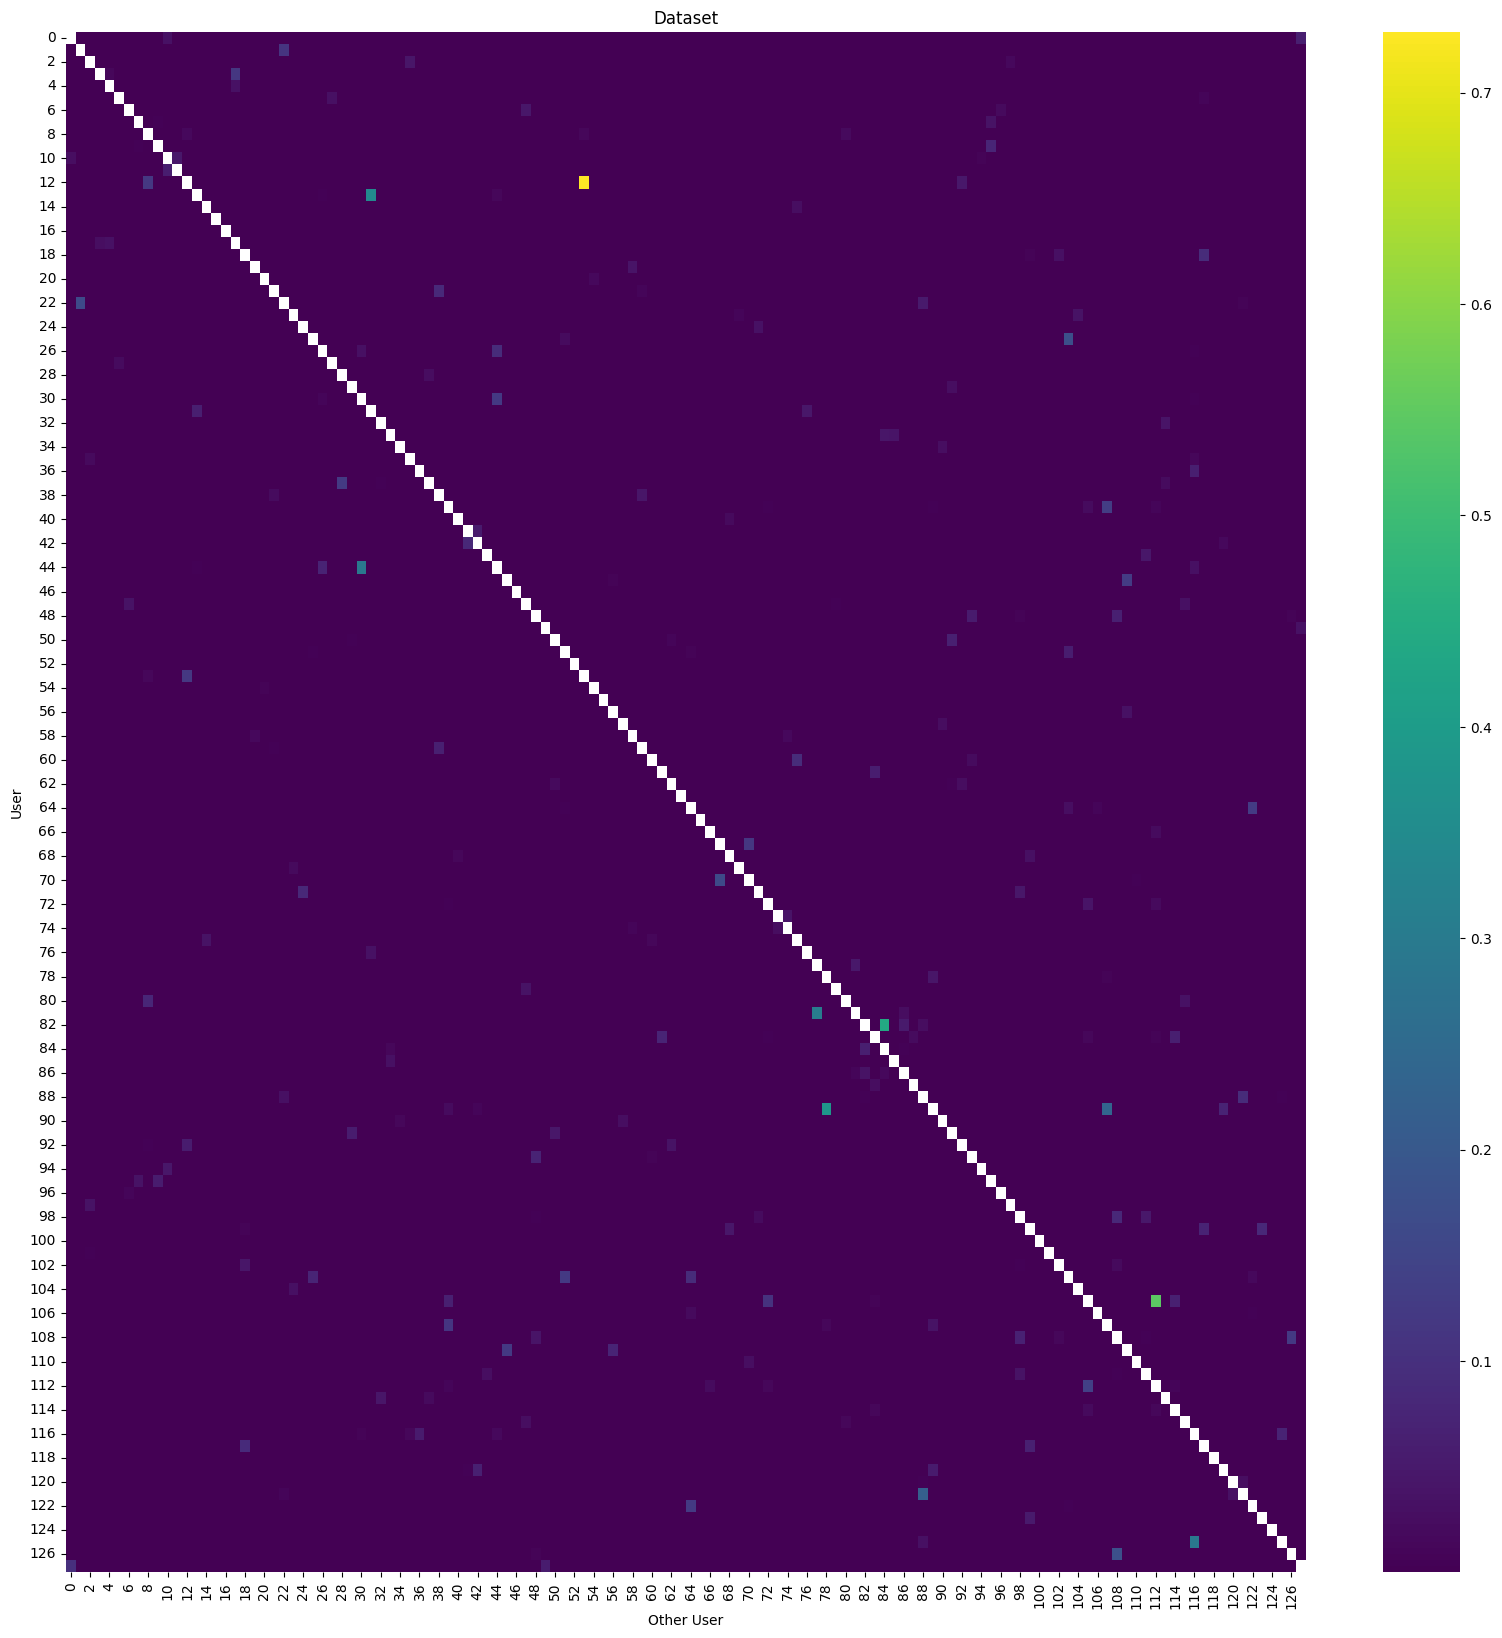

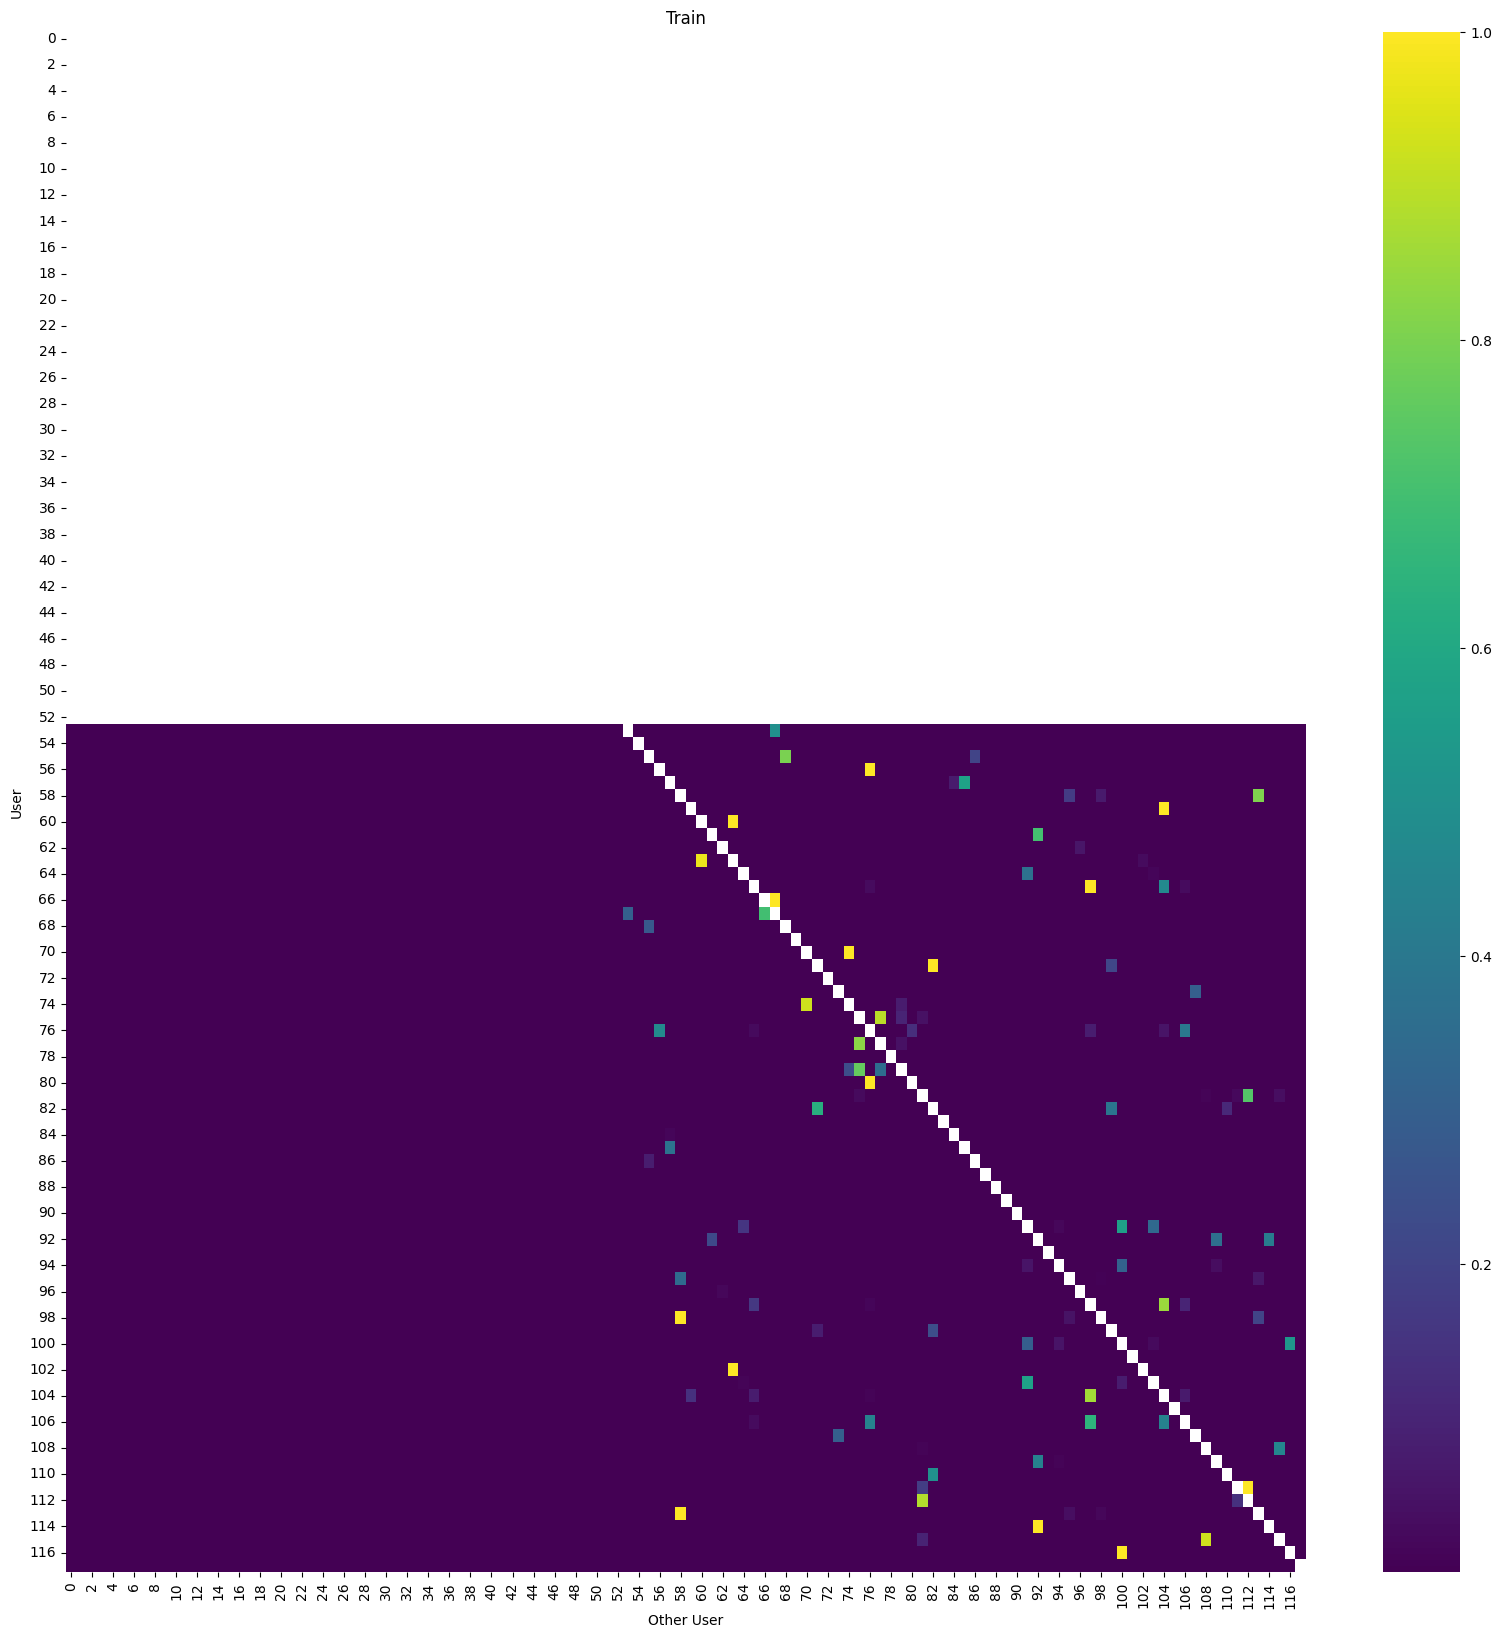

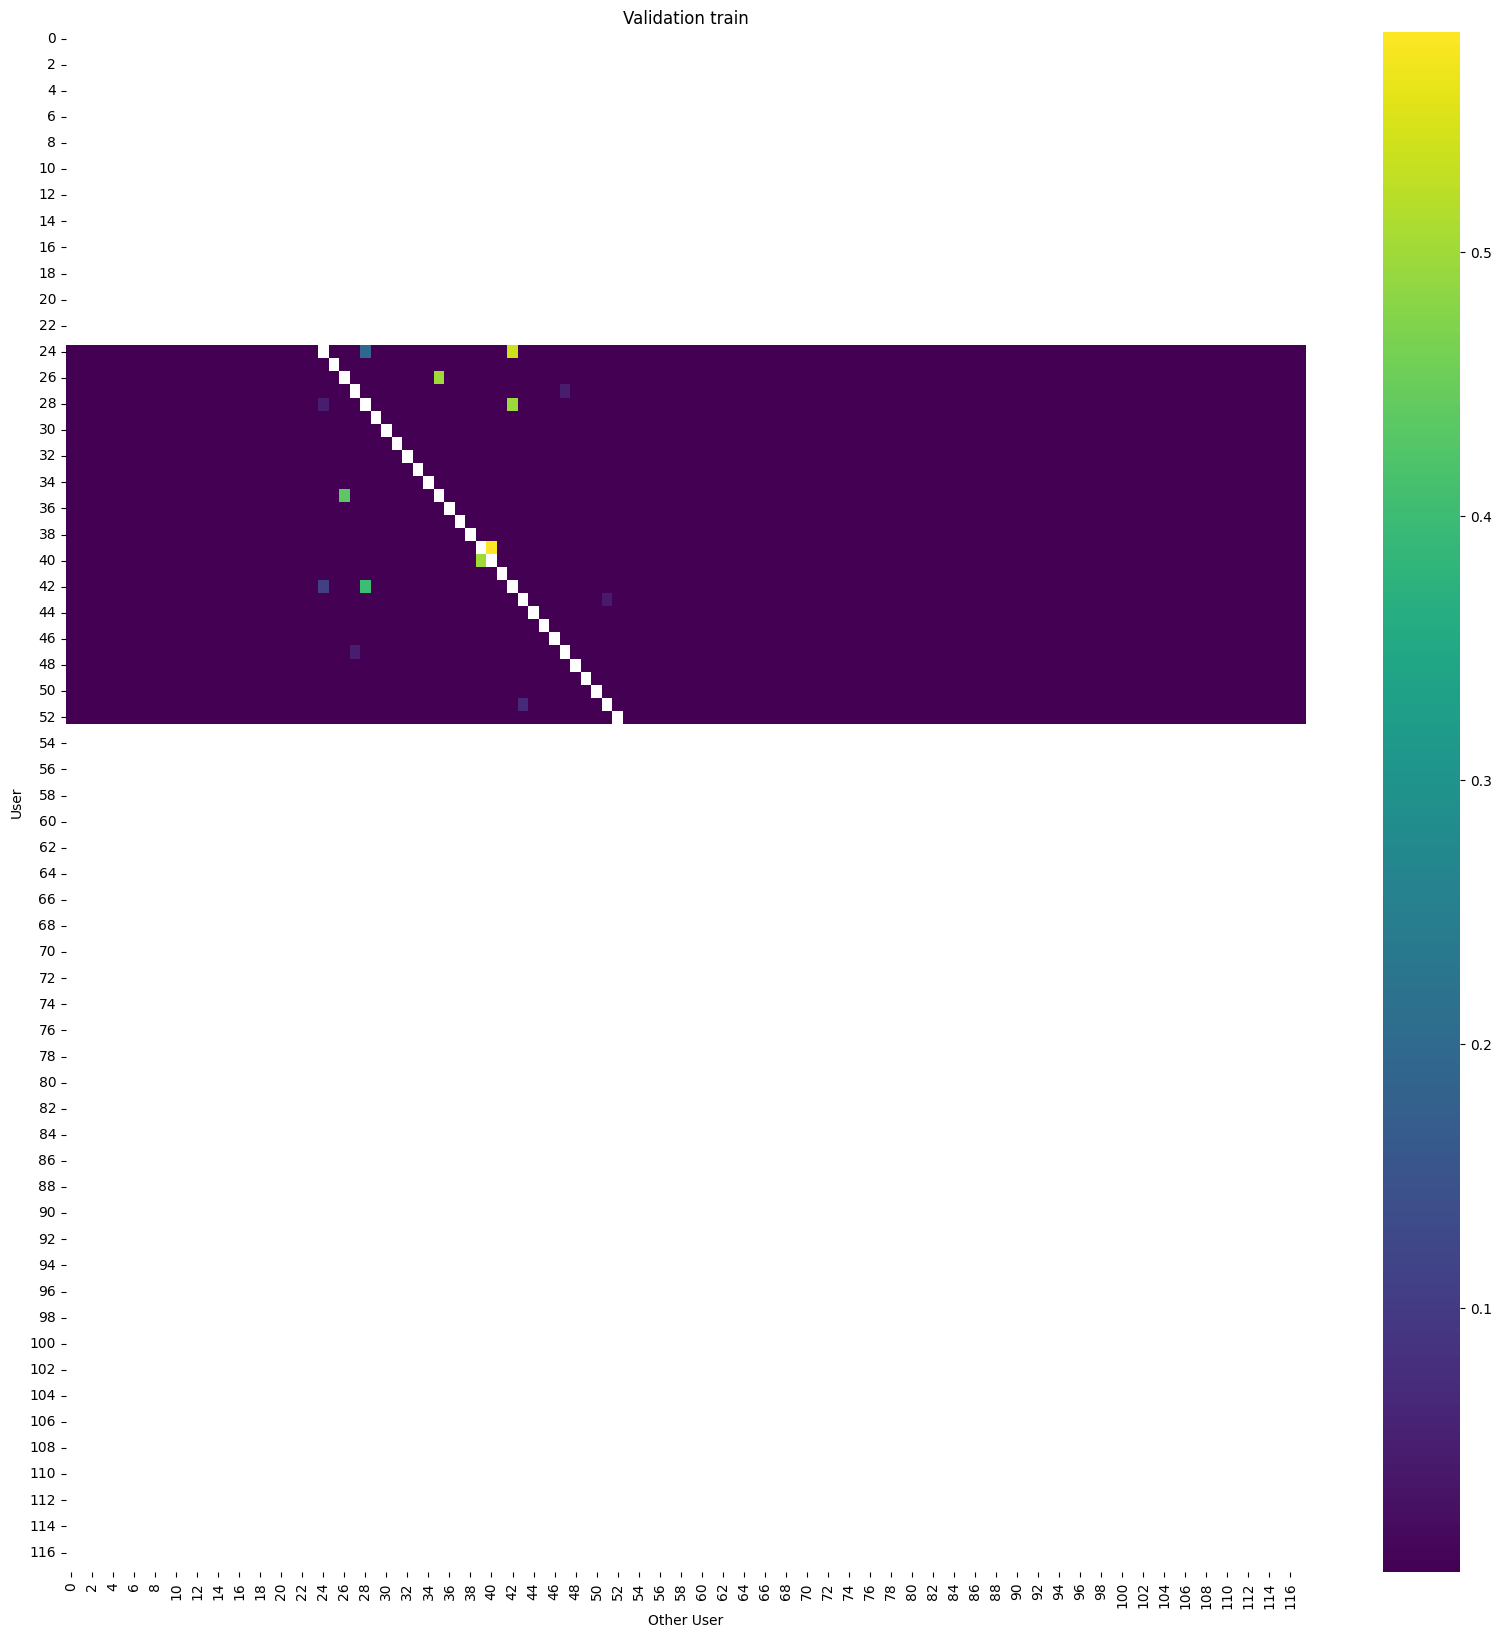

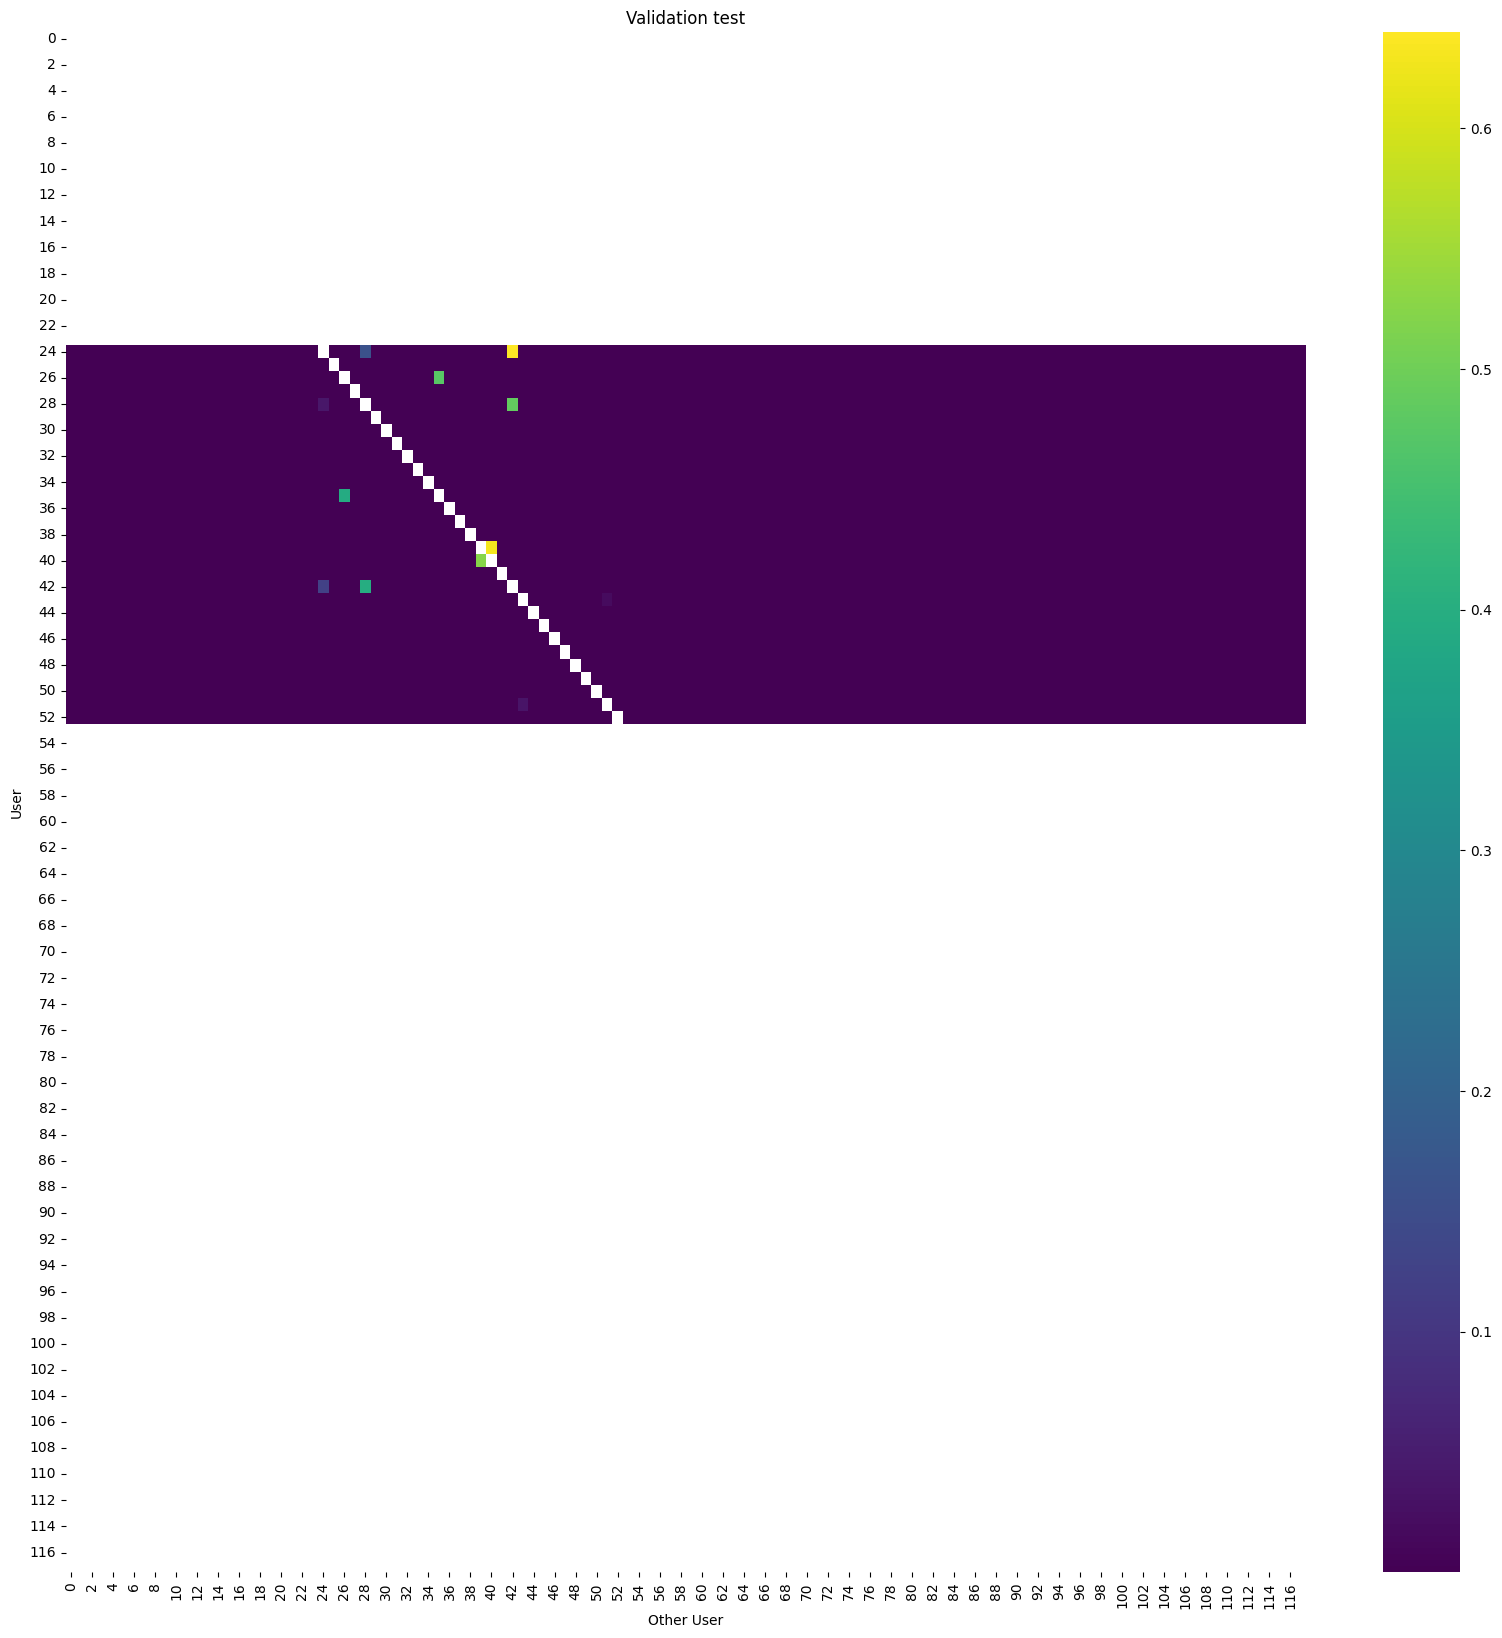

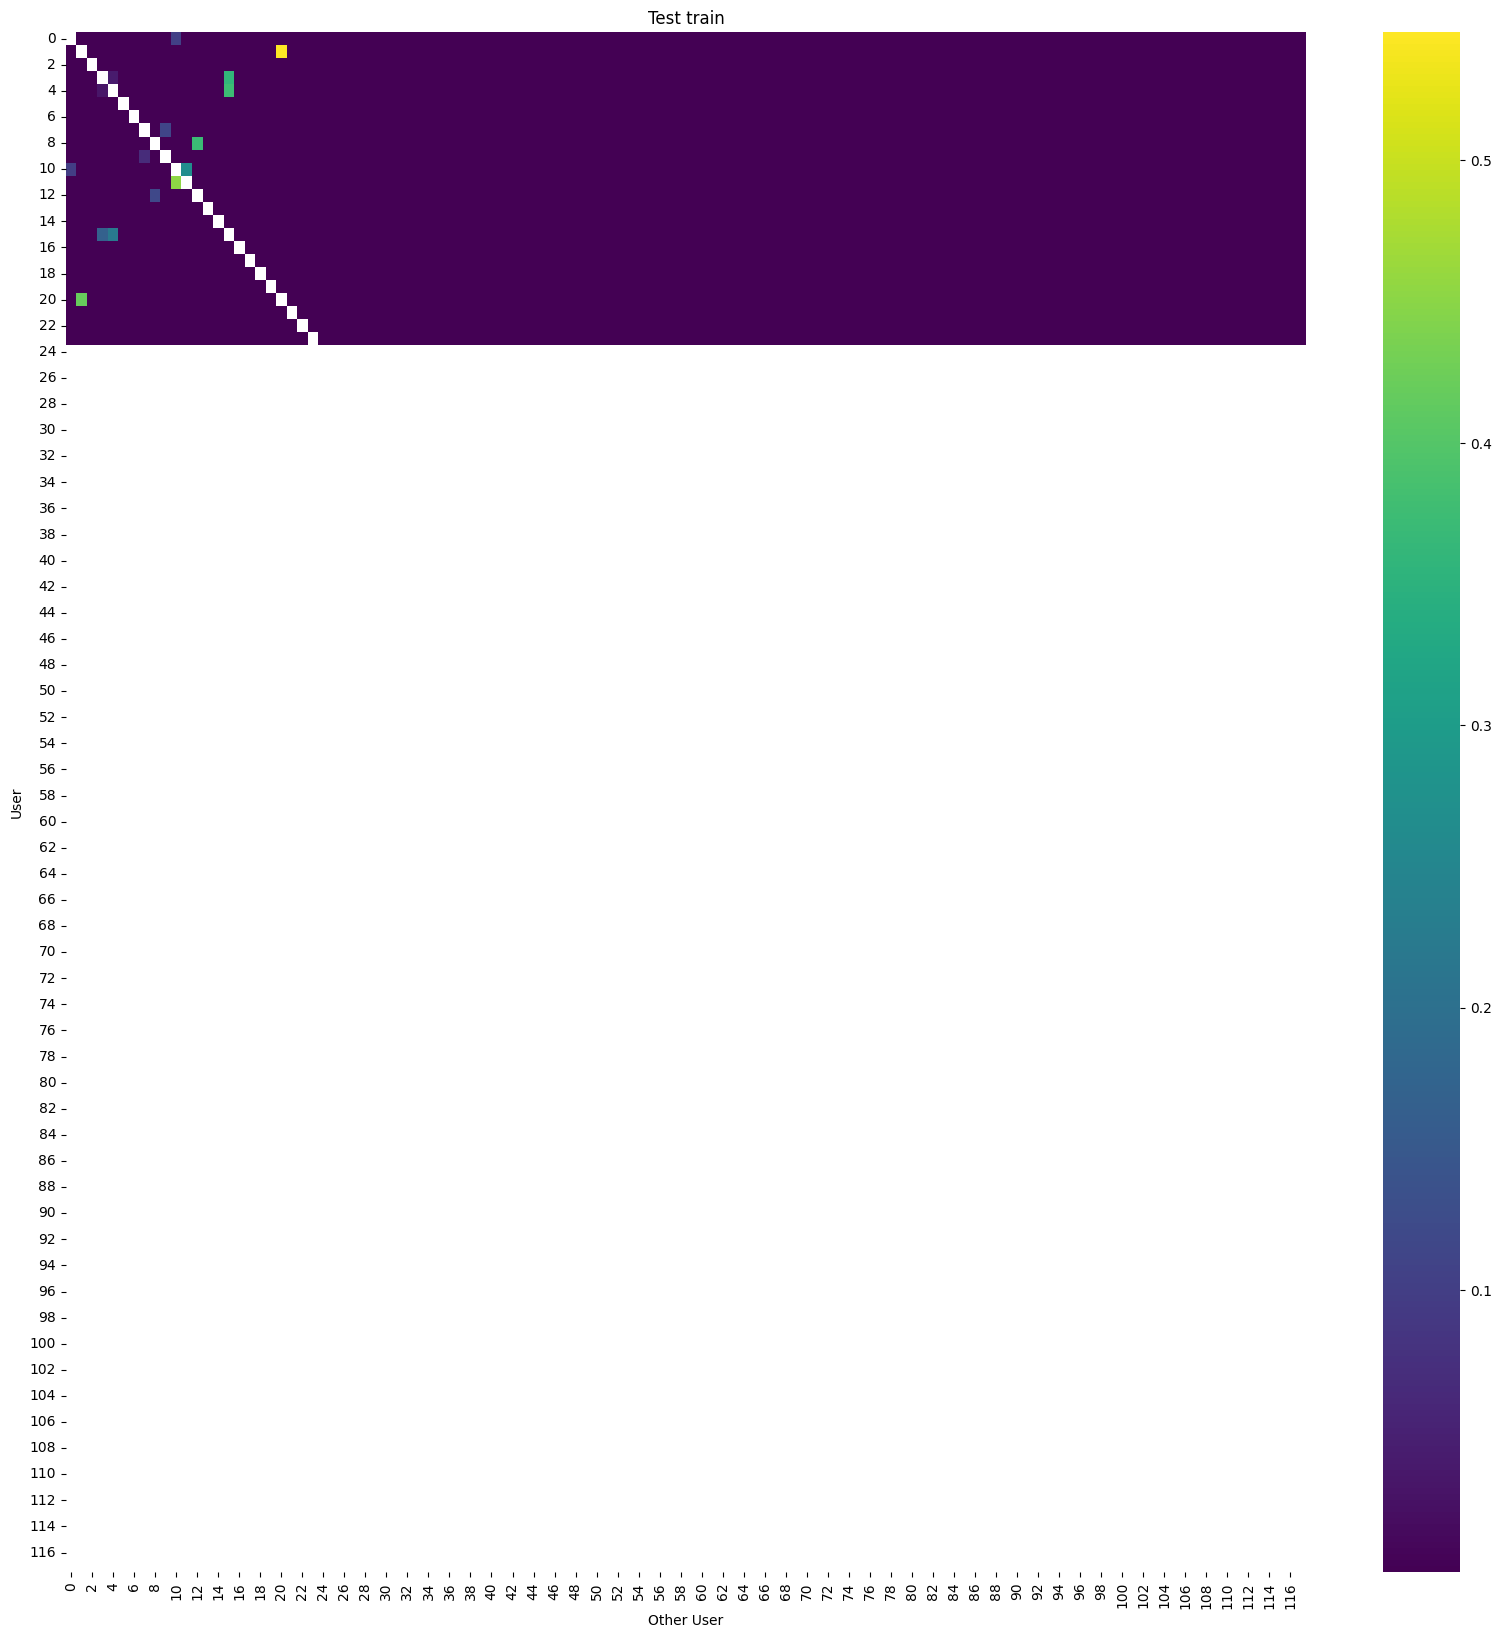

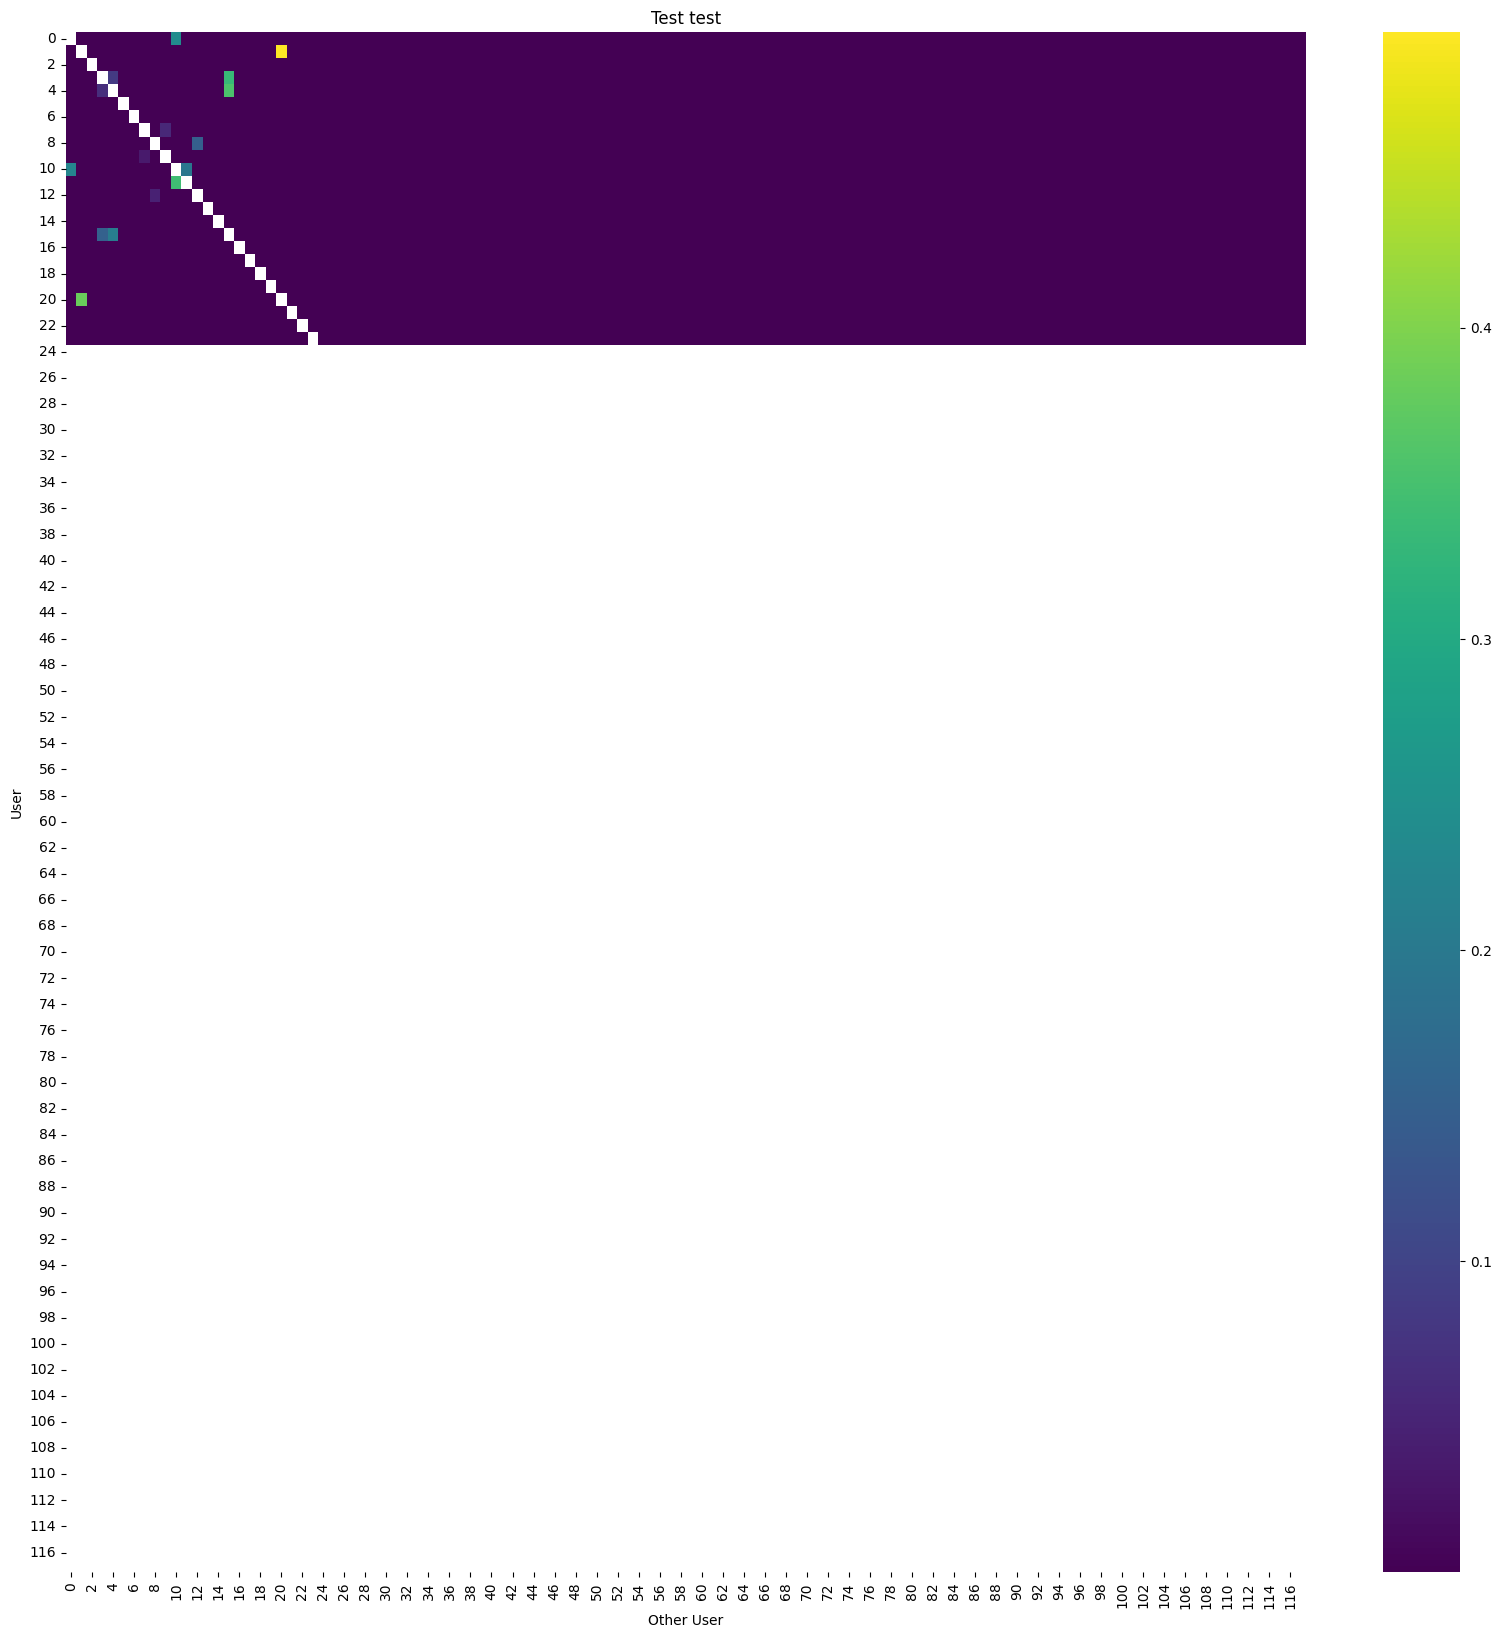

Alpha: 56.64979934692383
Min max affinity: 0.0 78.46290588378906
Min max affinity: 0.0 78.46290588378906
Min max affinity: 0.0 75.62854766845703
Min max affinity: 0.0 73.46046447753906
Min max affinity: 0.0 73.41495513916016
Min max affinity: 0.0 76.68059539794922
Max affinity: 78.46290588378906


In [65]:
df_train = df_matrix_mf_filtered[df_matrix_mf_filtered["username"].isin(train_users_df.index)]
# train_df["username"] = train_df["username"].cat.remove_unused_categories()
# train_df["id"] = train_df["id"].cat.remove_unused_categories()
print("Train data:")
display(df_train)

val_df_train, val_df_test = preprocessing.populate_train_test_dataframes(
    df=df_matrix_mf_filtered,
    selected_users=val_users_df,
    test_percentage=0.5,
    min_items_threshold=2,
)
# val_df_train["username"] = val_df_train["username"].cat.remove_unused_categories()
# val_df_test["username"] = val_df_test["username"].cat.remove_unused_categories()
# val_df_train["id"] = val_df_train["id"].cat.remove_unused_categories()
# val_df_test["id"] = val_df_test["id"].cat.remove_unused_categories()
print("Validation train data:")
display(val_df_train)
print("Validation test data:")
display(val_df_test)

test_df_train, test_df_test = preprocessing.populate_train_test_dataframes(
    df=df_matrix_mf_filtered,
    selected_users=test_users_df,
    test_percentage=0.5,
    min_items_threshold=2,
)
# test_df_train["username"] = test_df_train["username"].cat.remove_unused_categories()
# test_df_test["username"] = test_df_test["username"].cat.remove_unused_categories()
# test_df_train["id"] = test_df_train["id"].cat.remove_unused_categories()
# test_df_test["id"] = test_df_test["id"].cat.remove_unused_categories()
print("Test train data:")
display(test_df_train)
print("Test test data:")
display(test_df_test)

df_user_similarities = user_similarities.calculate_users_track_common_percentage(df, username_col="username", trackname_col="id")
plotting.plot_user_similarities_matrix(df_user_similarities, figsize=(20, 20), lower_triangle=False, title="Dataset")

df_user_similarities = user_similarities.calculate_users_track_common_percentage(df_train, username_col="username", trackname_col="id")
plotting.plot_user_similarities_matrix(df_user_similarities, figsize=(20, 20), lower_triangle=False, title="Train")

df_user_similarities = user_similarities.calculate_users_track_common_percentage(val_df_train, username_col="username", trackname_col="id")
plotting.plot_user_similarities_matrix(df_user_similarities, figsize=(20, 20), lower_triangle=False, title="Validation train")

df_user_similarities = user_similarities.calculate_users_track_common_percentage(val_df_test, username_col="username", trackname_col="id")
plotting.plot_user_similarities_matrix(df_user_similarities, figsize=(20, 20), lower_triangle=False, title="Validation test")

df_user_similarities = user_similarities.calculate_users_track_common_percentage(test_df_train, username_col="username", trackname_col="id")
plotting.plot_user_similarities_matrix(df_user_similarities, figsize=(20, 20), lower_triangle=False, title="Test train")

df_user_similarities = user_similarities.calculate_users_track_common_percentage(test_df_test, username_col="username", trackname_col="id")
plotting.plot_user_similarities_matrix(df_user_similarities, figsize=(20, 20), lower_triangle=False, title="Test test")

(
    whole_matrix_dataset,
    train_matrix_dataset,
    validation_train_matrix_dataset,
    validation_test_matrix_dataset,
    test_train_matrix_dataset,
    test_test_matrix_dataset,
) = (
    MatrixDataset(
        df=df_matrix_mf_filtered,
        user_col="username",
        item_col="id",
        value_col="affinity",
        device=device,
        dtype=dtype,
    ),
    MatrixDataset(
        df=df_train,
        user_col="username",
        item_col="id",
        value_col="affinity",
        device=device,
        dtype=dtype,
    ),
    MatrixDataset(
        df=val_df_train,
        user_col="username",
        item_col="id",
        value_col="affinity",
        device=device,
        dtype=dtype,
    ),
    MatrixDataset(
        df=val_df_test,
        user_col="username",
        item_col="id",
        value_col="affinity",
        device=device,
        dtype=dtype,
    ),
    MatrixDataset(
        df=test_df_train,
        user_col="username",
        item_col="id",
        value_col="affinity",
        device=device,
        dtype=dtype,
    ),
    MatrixDataset(
        df=test_df_test,
        user_col="username",
        item_col="id",
        value_col="affinity",
        device=device,
        dtype=dtype,
    ),
)

a = whole_matrix_dataset.compute_alpha()
whole_matrix_dataset.set_alpha(a)
# min_scale, max_scale = whole_matrix_dataset.min_max_scale(bounds=(0.0, 1.0))

for dataset in [train_matrix_dataset, validation_train_matrix_dataset, validation_test_matrix_dataset, test_train_matrix_dataset, test_test_matrix_dataset]:
    dataset.set_alpha(a)
    # dataset.min_max_scale(bounds=(0.0, 1.0), optimums=(min_scale, max_scale))

print(f"Alpha: {a}")
print(f"Min max affinity: {whole_matrix_dataset.R.min().item()} {whole_matrix_dataset.R.max().item()}")
print(f"Min max affinity: {train_matrix_dataset.R.min().item()} {train_matrix_dataset.R.max().item()}")
print(f"Min max affinity: {validation_train_matrix_dataset.R.min().item()} {validation_train_matrix_dataset.R.max().item()}")
print(f"Min max affinity: {validation_test_matrix_dataset.R.min().item()} {validation_test_matrix_dataset.R.max().item()}")
print(f"Min max affinity: {test_train_matrix_dataset.R.min().item()} {test_train_matrix_dataset.R.max().item()}")
print(f"Min max affinity: {test_test_matrix_dataset.R.min().item()} {test_test_matrix_dataset.R.max().item()}")

max_affinity = whole_matrix_dataset.R.max().item()
print(f"Max affinity: {max_affinity}")

In [66]:
print("Whole dataset shape:", whole_matrix_dataset.R.shape)
print("Train dataset shape:", train_matrix_dataset.R.shape)
print("Validation train dataset shape:", validation_train_matrix_dataset.R.shape)
print("Validation test dataset shape:", validation_test_matrix_dataset.R.shape)
print("Test train dataset shape:", test_train_matrix_dataset.R.shape)
print("Test test dataset shape:", test_test_matrix_dataset.R.shape)

Whole dataset shape: torch.Size([118, 4961])
Train dataset shape: torch.Size([118, 4961])
Validation train dataset shape: torch.Size([118, 4961])
Validation test dataset shape: torch.Size([118, 4961])
Test train dataset shape: torch.Size([118, 4961])
Test test dataset shape: torch.Size([118, 4961])


In [67]:
whole_matrix_dataset.R

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]], device='mps:0')

In [68]:
train_dataset = TensorDataset(train_matrix_dataset.R)
validation_dataset = TensorDataset(validation_train_matrix_dataset.R, validation_test_matrix_dataset.R)
test_dataset = TensorDataset(test_train_matrix_dataset.R, test_test_matrix_dataset.R)

# Define and train the MultiVAE model

In [69]:
p_dims = [200, 600, whole_matrix_dataset.R.shape[1]]
model = MultiVAE(p_dims=p_dims).to(device=device, dtype=dtype)
model

MultiVAE(
  (q_layers): ModuleList(
    (0): Linear(in_features=4961, out_features=600, bias=True)
    (1): Linear(in_features=600, out_features=400, bias=True)
  )
  (p_layers): ModuleList(
    (0): Linear(in_features=200, out_features=600, bias=True)
    (1): Linear(in_features=600, out_features=4961, bias=True)
  )
  (drop): Dropout(p=0.5, inplace=False)
)

In [70]:
list(train_users_df.index.codes)

[117,
 116,
 115,
 114,
 113,
 112,
 111,
 110,
 109,
 108,
 107,
 106,
 105,
 104,
 103,
 102,
 101,
 100,
 99,
 98,
 97,
 96,
 95,
 94,
 93,
 92,
 91,
 90,
 89,
 88,
 87,
 86,
 85,
 84,
 83,
 82,
 81,
 80,
 79,
 78,
 77,
 76,
 75,
 74,
 73,
 72,
 71,
 70,
 69,
 68,
 67,
 66,
 65,
 64,
 63,
 62,
 61,
 60,
 59,
 58,
 57,
 56,
 55,
 54,
 53]

In [71]:
batch_size = 1
anneal_cap = 0.2
total_anneal_steps = 200000
max_item = 25

optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)

start_time = time.time()
(
    best_model,
    loss_history,
    validation_loss_history,
    ndcg_history,
    r20_history,
    r50_history,
    mpr_history,
    similarity_train_history,
    similarity_val_history,
) = model.train_model(
    optimizer,
    train_loader,
    num_epochs=100 + 1,
    anneal_cap=anneal_cap,
    total_anneal_steps=total_anneal_steps,
    device=device,
    dtype=dtype,
    validation_dataloader=validation_loader,
    validation_features_df=df_matrix_mf,
    validation_user_item_matrix=whole_matrix_dataset.R,
    validation_features_columns=spoti.NUMERICAL_FEATURES,
    validation_users_train=list(train_users_df.index.codes),
    validation_users_val=list(train_users_df.index.codes) + list(val_users_df.index.codes),
    log_interval=1,
    validation_similarity_max_item=max_item,
)
end_time = time.time()

Best model found at epoch 0 with score: -13.625504
Epoch: 0 	 Loss: 24397.396484 	 Val Loss: 4600.403809 	 NDCG_100: 0.000788 	 Recall_20: 0.003448 	 Recall_50: 0.002069 	 MPR: 0.512480, 	 Similarity Score (train): -13.625504 	 Similarity Score (validation): -13.625504
Best model found at epoch 1 with score: -13.456254
Epoch: 1 	 Loss: 23148.412109 	 Val Loss: 4656.782715 	 NDCG_100: 0.001168 	 Recall_20: 0.003448 	 Recall_50: 0.003448 	 MPR: 0.487278, 	 Similarity Score (train): -13.456254 	 Similarity Score (validation): -13.456254
Epoch: 2 	 Loss: 21116.939453 	 Val Loss: 4477.507812 	 NDCG_100: 0.006442 	 Recall_20: 0.013793 	 Recall_50: 0.024013 	 MPR: 0.380777, 	 Similarity Score (train): -13.521431 	 Similarity Score (validation): -13.521431
Epoch: 3 	 Loss: 20329.033203 	 Val Loss: 4289.595703 	 NDCG_100: 0.046306 	 Recall_20: 0.131034 	 Recall_50: 0.196038 	 MPR: 0.347948, 	 Similarity Score (train): -13.542712 	 Similarity Score (validation): -13.542712
Epoch: 4 	 Loss: 18310

In [72]:
losses_df = pd.DataFrame(
    [
        loss_history,
        validation_loss_history,
        ndcg_history,
        r20_history,
        r50_history,
        mpr_history,
        similarity_train_history,
        similarity_val_history,
    ]
).T
losses_df.columns = [
    "loss",
    "validation_loss",
    "ndgk",
    "r20",
    "r50",
    "mpr",
    "similarity_train",
    "similarity_val",
]

px.line(
    losses_df, x=losses_df.index, y=["loss", "validation_loss"], title="Loss"
).show()
px.line(
    losses_df,
    x=losses_df.index,
    y=["ndgk", "r20", "r50", "mpr", "similarity_train", "similarity_val"],
    title="Metrics",
).show()

In [73]:
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)
total_loss, ndcg, recall_20, recall_50, mpr, similarity_train, similarity_val = best_model.evaluate_model(
    test_loader,
    anneal_cap=anneal_cap,
    total_anneal_steps=total_anneal_steps,
    df_features=df_matrix_mf,
    user_item_matrix=whole_matrix_dataset.R,
    features_columns=spoti.NUMERICAL_FEATURES,
    users_train=list(train_users_df.index.codes) + list(val_users_df.index.codes),
    users_validation=list(train_users_df.index.codes) + list(val_users_df.index.codes) + list(test_users_df.index.codes),
    similarity_max_item=max_item,
    device=device,
    dtype=dtype,
)
print(f"Total loss: {total_loss:.2f}")
print(f"Similarity (train): {similarity_train_history.max():.2f}")
print(f"Similarity (val): {similarity_train:.2f}")
print(f"Similarity (test): {similarity_val:.2f}")
print(f"Generalisation capability: {np.std([similarity_train_history.cpu().max().item(), similarity_train.cpu().item(), similarity_val.cpu().item()]):.2f}")
print(f"MPR: {mpr:.2f}")
print(f"NDCG_100: {ndcg:.3f}")
print(f"Recall_50: {recall_50:.2f}")
print(f"Recall_20: {recall_20:.2f}")
print(f"Time: {end_time - start_time:.2f}s")

Total loss: 5039.25
Similarity (train): -13.37
Similarity (val): -13.39
Similarity (test): -13.42
Generalisation capability: 0.02
MPR: 0.37
NDCG_100: 0.056
Recall_50: 0.25
Recall_20: 0.26
Time: 731.38s


# Plot the users latent distributions

In [74]:
# retrieve users latent representations (mean and variance)
user_names = df_matrix_mf["username"].sort_values().unique().tolist()

In [75]:
z, mu, std, logvar = model.get_latent_representations(whole_matrix_dataset.R)

print(z.shape)
print(mu.shape)
print(std.shape)
print(logvar.shape)

torch.Size([118, 200])
torch.Size([118, 200])
torch.Size([118, 200])
torch.Size([118, 200])


In [76]:
# Define the number of points for grid, the width of the gaussian curves and color map
# dim1 = range(0, p_dims[0])
# dim2 = range(0, p_dims[0])
dim1 = range(1, 5)
dim2 = range(1, 5)

# for i in dim1:
#     for j in dim2:
#         if i >= j:
#             continue
#         # # Plot 2D latent space using and add annotations with usernames
#         # fig = px.scatter(x=z[:, i], y=z[:, j], hover_name=usersnames, color=usersnames)
#         # fig.update_traces(marker=dict(size=10))
#         # fig.update_layout(title="2D Latent Space")
#         # # Show the usernames next to the points
#         # for i_username, username in enumerate(usersnames):
#         #     fig.add_annotation(
#         #         x=z[i_username, i], y=z[i_username, j], text=username, showarrow=False, xshift=-20, yshift=15
#         #     )
#         # fig.show()
        
#         # Using sns
#         fig, ax = plt.subplots(figsize=(10, 5))
#         sns.scatterplot(x=z[:, i], y=z[:, j], hue=usersnames, ax=ax)
#         for i_username, username in enumerate(usersnames):
#             ax.text(z[i_username, i], z[i_username, j] + 0.3, username, fontsize=8)
#         ax.set_title(f"2D Latent Space ({i}, {j})")
#         ax.set_xlabel(f"z{i}")
#         ax.set_ylabel(f"z{j}")
#         plt.show()

<Figure size 1000x1000 with 0 Axes>

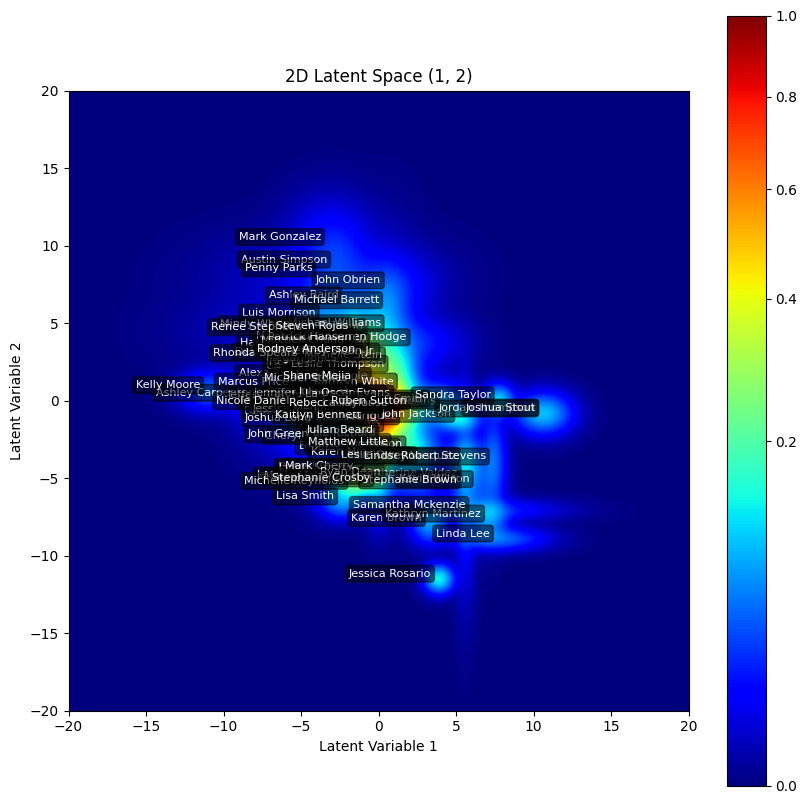

<Figure size 1000x1000 with 0 Axes>

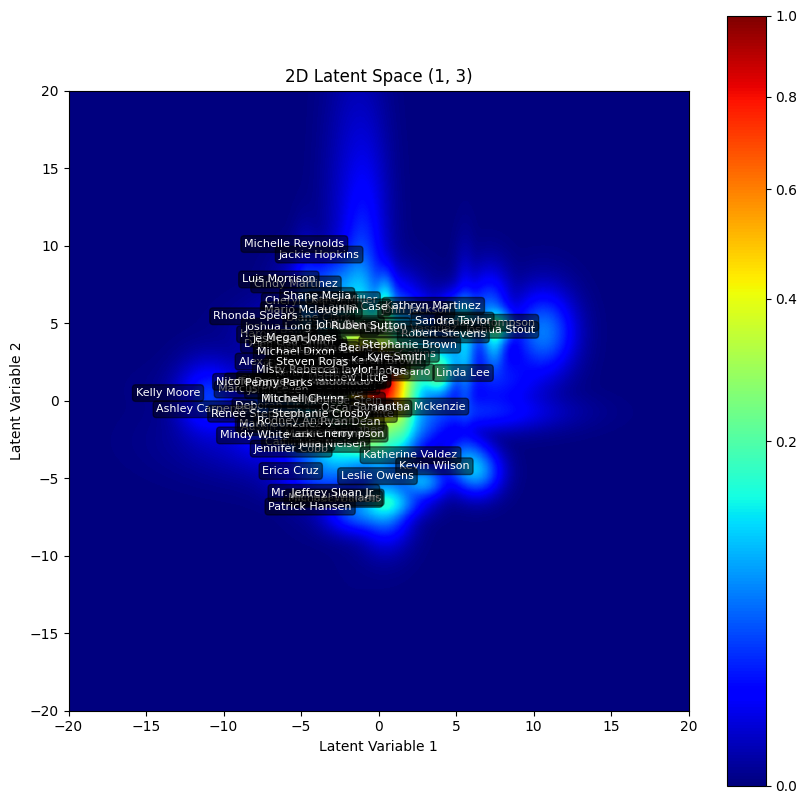

<Figure size 1000x1000 with 0 Axes>

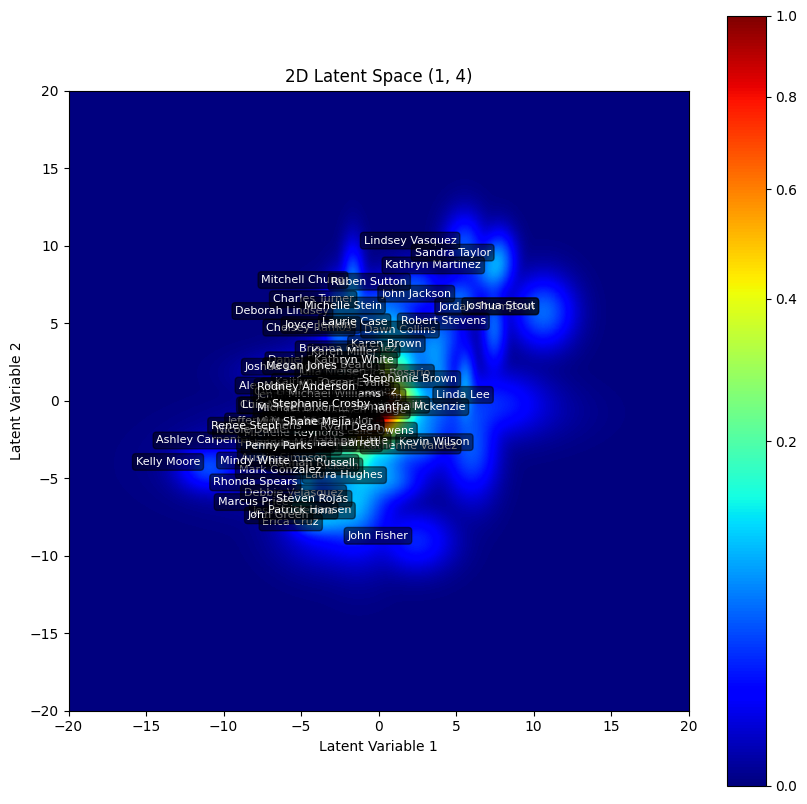

<Figure size 1000x1000 with 0 Axes>

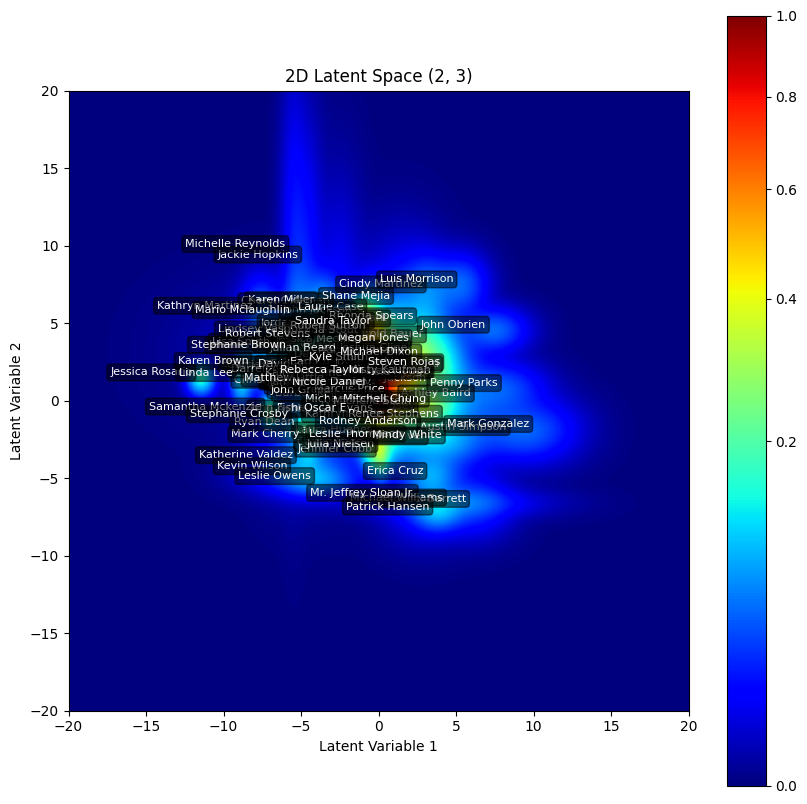

<Figure size 1000x1000 with 0 Axes>

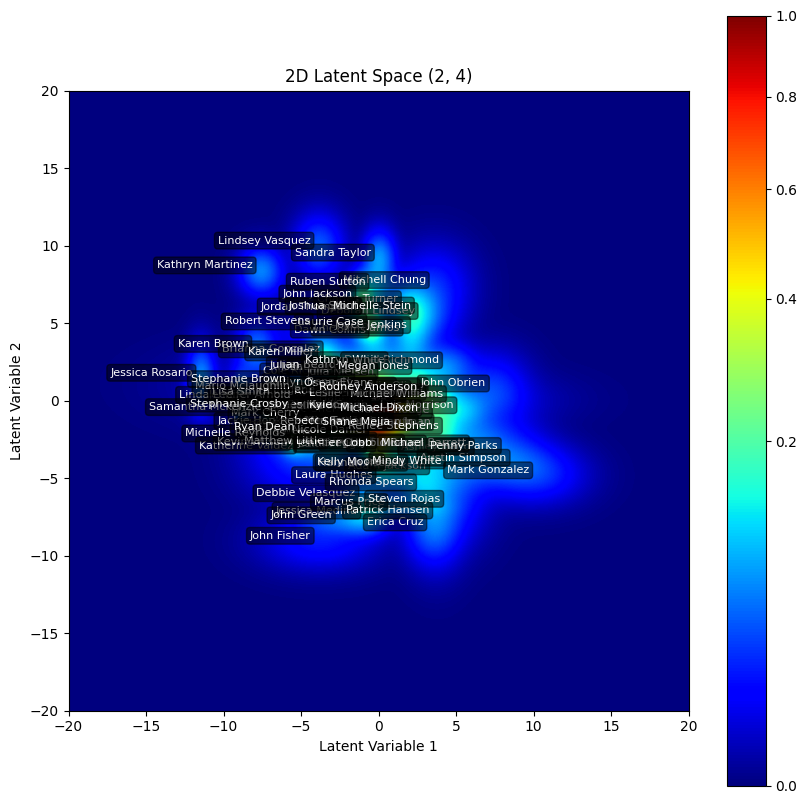

<Figure size 1000x1000 with 0 Axes>

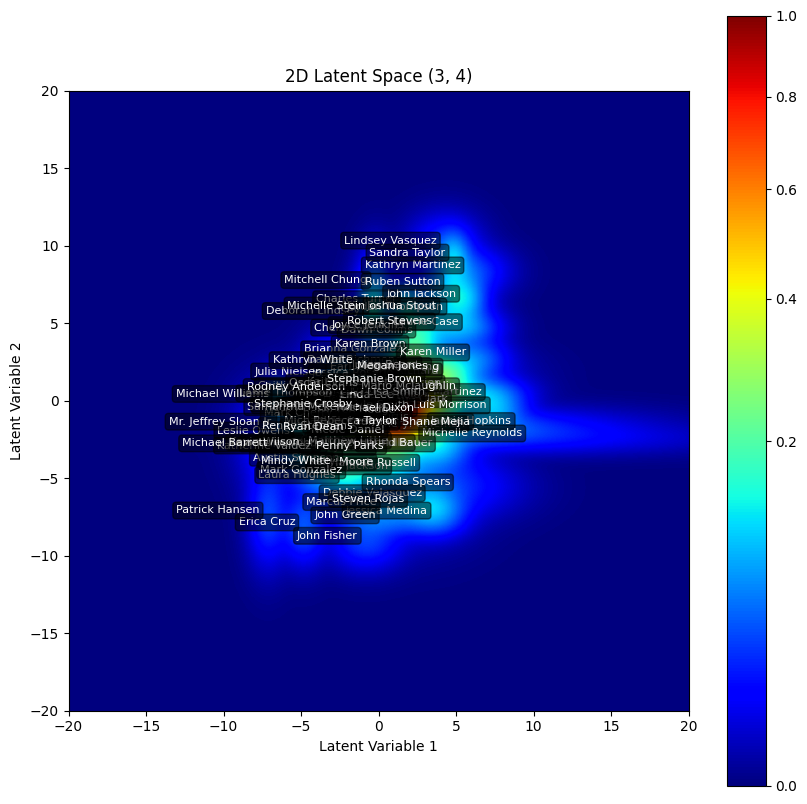

In [77]:
for i in dim1:
    for j in dim2:
        if i >= j:
            continue
        plt.figure(figsize=(10, 10))
        plotting.plot_multivariate_gaussian_image_with_labels(
            mu.cpu().numpy()[:, [i, j]],
            std.cpu().numpy()[:, [i, j]],
            color_map="jet",
            x_bounds=(-20, 20),
            y_bounds=(-20, 20),
            figsize=(10, 10),
            num_points=500,
            # dpi=300,
            labels=user_names,
            title=f"2D Latent Space ({i}, {j})",
        )

# Perform recommendations

In [78]:
username = "timothy"
user_id = whole_matrix_dataset.usernames_to_ids([username])[0]
username = whole_matrix_dataset.ids_to_usernames([user_id])[0]
print(f"User id: {user_id}, {username}")
user_seen = whole_matrix_dataset.get_interactions_ids(user_id)
user_seen.cpu().numpy().shape

User id: -1, Yvonne Chapman


(138,)

In [79]:
user_seen.cpu().numpy()

array([  28,  153,  204,  235,  446,  470,  608,  647,  663,  700,  701,
        721,  773,  806,  828,  843,  847,  878,  898,  979, 1006, 1014,
       1052, 1066, 1122, 1218, 1275, 1283, 1305, 1309, 1371, 1379, 1394,
       1434, 1455, 1471, 1473, 1525, 1562, 1602, 1666, 1728, 1780, 1805,
       1811, 1835, 1853, 1855, 1887, 1909, 1913, 1944, 1952, 1955, 1971,
       1979, 1994, 2035, 2059, 2215, 2254, 2298, 2328, 2332, 2432, 2438,
       2467, 2492, 2514, 2523, 2529, 2575, 2613, 2616, 2649, 2693, 2741,
       2747, 2764, 2803, 2952, 2980, 2995, 3029, 3043, 3053, 3072, 3110,
       3121, 3131, 3156, 3163, 3216, 3253, 3266, 3364, 3405, 3415, 3427,
       3438, 3626, 3658, 3735, 3755, 3786, 3791, 3820, 3971, 4031, 4041,
       4043, 4099, 4108, 4111, 4138, 4162, 4252, 4254, 4336, 4339, 4355,
       4395, 4525, 4536, 4565, 4571, 4640, 4653, 4704, 4724, 4742, 4757,
       4771, 4779, 4863, 4901, 4936, 4938])

## Retrieve similar users in the most similar order

In [80]:
similar_users_ids = best_model.sort_similar_users(user_id=user_id, latent_representations=z)
most_similar_users = whole_matrix_dataset.ids_to_usernames(similar_users_ids.cpu().numpy())[1:]
most_similar_users

['Adam Jackson',
 'Jacqueline Morton',
 'Luis Morrison',
 'Samantha Mckenzie',
 'Lindsey Vasquez',
 'Harold Bauer',
 'Cameron Ochoa',
 'Timothy Hampton',
 'Stephanie Brown',
 'Rebecca Taylor',
 'Steven Rojas',
 'Mindy White',
 'Darrell Allen',
 'Alexander Browning',
 'Kathryn Martinez',
 'Julian Beard',
 'Brianna Gonzalez',
 'Christine Adams',
 'Caitlin Page',
 'Amy Jones',
 'Clifford Nichols',
 'Jessica Medina',
 'Carrie Thompson',
 'Bernard Parker',
 'Alex Ayers',
 'Andrew Russell',
 'Amanda Long',
 'Jennifer Cobb',
 'Mitchell Chung',
 'Leslie Owens',
 'Brian Marks',
 'Cindy Martinez',
 'Renee Stephens',
 'Jackie Hopkins',
 'Erica Cruz',
 'Michael Stokes',
 'Lauren Hodge',
 'Sandra Taylor',
 'Toni Schwartz',
 'Felicia Clark',
 'David Rodriguez',
 'John Green',
 'Christopher Pennington',
 'Linda Lee',
 'Megan Jones',
 'Bradley Thomas',
 'Kyle Smith',
 'Dawn Collins',
 'Deborah Lindsey',
 'John Fisher',
 'James Maldonado',
 'Charles Turner',
 'Diane Clark',
 'Michael Barrett',
 'Cole R

## Get recommended tracks

In [81]:
items_ids, predicted_scores = best_model.recommend(matrix=whole_matrix_dataset.R)
recommendation_df: pd.DataFrame = whole_matrix_dataset.df.copy()
recommendation_df["item_id"] = recommendation_df["id"].cat.codes.astype("int")
recommendation_df.set_index("item_id", inplace=True)

# Get df in the same order as the ids
recommendation_df = recommendation_df.loc[items_ids.cpu().numpy()[user_id]]
recommendation_df["predicted_scores"] = pd.Series(predicted_scores.cpu().numpy()[user_id], index=items_ids.cpu().numpy()[user_id])

recommendation_df = recommendation_df[recommendation_df["username"] != username]
recommendation_df = recommendation_df.drop_duplicates(subset=["username", "id"])
recommendation_df["seen"] = recommendation_df.index.isin(user_seen.cpu().numpy())
# recommendation_df = recommendation_df[recommendation_df["seen"] == False]
recommendation_df = recommendation_df.drop_duplicates(subset=["id"])
recommendation_df = recommendation_df.sort_values(by="predicted_scores", ascending=False)

columns = spoti.PRETTY_PRINT_FEATURES
columns = list(recommendation_df.columns)
recommendation_df[["id", "predicted_scores", "seen"] + columns].head(30)[spoti.PRETTY_PRINT_FEATURES]

,username,id,id,danceability,instrumentalness,duration_ms
item_id,,,,,,
2514,Adam Jackson,Manager animal environment. Call production tr...,Manager animal environment. Call production tr...,-1.689642,0.549444,0.962467
3216,Jacqueline Morton,Politics here purpose Congress officer as eye,Politics here purpose Congress officer as eye,-0.780418,1.699516,-0.389797
2332,Jacqueline Morton,Leave expert figure happy commercial especially,Leave expert figure happy commercial especially,0.400048,-0.567902,0.633048
2693,Adam Jackson,Most kind yeah evidence PM. North need she pus...,Most kind yeah evidence PM. North need she pus...,0.250020,-0.176180,0.640310
4901,Adam Jackson,Yard during available effect agreement course,Yard during available effect agreement course,0.406947,-0.236499,-1.462402
828,Barbara Love,Claim parent we election,Claim parent we election,-0.242465,0.690436,1.669835
4757,Adam Jackson,While left old former. Black remain group want,While left old former. Black remain group want,1.400913,-2.891957,-0.094157
2328,Jacqueline Morton,Least most well election or,Least most well election or,-0.233267,1.713499,-0.929534
773,Jacqueline Morton,Character people century car account purpose d...,Character people century car account purpose d...,1.485496,0.221824,-0.877591
